# Pseudo-Labeling Verification Notebook

Run the relational pseudo-labeler on DUT/CITR data and visually verify that mode assignments are correct.

**4 Modes:**
- **0 Aggressive** (red): conflict exists, pedestrian pushes through
- **1 Regular** (blue): no active conflict, normal walking
- **2 Cautious** (green): conflict exists, pedestrian yields
- **3 Following** (orange): crowd follower, inherits leader's behavior

# CITR V2P Interaction Experiment Data labelling

In [1]:
# Cell 1: Setup
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# >>> EDIT THESE PATHS <<<
# ============================================================
PROJECT_DIR = '.'   # folder containing mode_config.py, pseudo_labeler.py

# Choose your dataset:
# data_dir = r"/Volumes/Seagate129/P2V_Interaction_Modeling/Data/p2p_controlled"       # ped_only = True
data_dir = r"/Volumes/Seagate129/P2V_Interaction_Modeling/Data/v2p_controlled"       # ped_only = False
# data_dir = r"/Volumes/Seagate129/P2V_Interaction_Modeling/Data/campus_field"            # ped_only = False

ped_only = False
# ============================================================

sys.path.insert(0, PROJECT_DIR)
from pseudo_labeler import PseudoLabeler, FeatureExtractor, label_all_scenarios
from mode_config import NUM_MODES, MODE_NAMES

MODE_COLORS = {0: '#E74C3C', 1: '#3498DB', 2: '#2ECC71', 3: '#F39C12'}
MODE_LABELS = {0: 'Aggressive', 1: 'Regular', 2: 'Cautious', 3: 'Following'}

# Discover scenario files (same pattern as your GA notebook)
all_files = [f for f in os.listdir(data_dir) if f.endswith('.csv')]
print(f'Data directory: {data_dir}')
print(f'CSV files found: {len(all_files)}')

scenario_files = []
if ped_only:
    for f in all_files:
        scenario_files.append((f, None))
else:
    scenario_dict = {}
    for f in all_files:
        key = f.split('_traj_')[0]
        scenario_dict.setdefault(key, {})
        if '_ped_' in f:
            scenario_dict[key]['ped'] = f
        elif '_veh_' in f:
            scenario_dict[key]['veh'] = f
    for key, files in scenario_dict.items():
        ped = files.get('ped')
        veh = files.get('veh')
        if ped:
            scenario_files.append((ped, veh))

print(f'Scenarios discovered: {len(scenario_files)}')
for pf, vf in scenario_files[:5]:
    print(f'  ped: {pf}  |  veh: {vf}')

Data directory: /Volumes/Seagate129/P2V_Interaction_Modeling/Data/v2p_controlled
CSV files found: 52
Scenarios discovered: 26
  ped: back_interaction_04_traj_ped_filtered.csv  |  veh: back_interaction_04_traj_veh_filtered.csv
  ped: back_interaction_01_traj_ped_filtered.csv  |  veh: back_interaction_01_traj_veh_filtered.csv
  ped: back_interaction_02_traj_ped_filtered.csv  |  veh: back_interaction_02_traj_veh_filtered.csv
  ped: back_interaction_03_traj_ped_filtered.csv  |  veh: back_interaction_03_traj_veh_filtered.csv
  ped: front_interaction_04_traj_ped_filtered.csv  |  veh: front_interaction_04_traj_veh_filtered.csv


In [2]:
# Cell 2: Run Pseudo-Labeling
labels_df = label_all_scenarios(data_dir, ped_only=ped_only)

print(f'Total labeled samples: {len(labels_df)}')
print(f'\nMode distribution:')
print(labels_df['mode_name'].value_counts().to_string())
print(f'\nConflict rate: {labels_df["has_conflict"].mean()*100:.1f}%')
print(f'Follower rate: {labels_df["is_follower"].mean()*100:.1f}%')
labels_df.head(10)

Total labeled samples: 1016

Mode distribution:
mode_name
regular       540
following     442
aggressive     24
cautious       10

Conflict rate: 20.8%
Follower rate: 43.5%


,ped_id,frame_start,frame_end,mode,mode_name,has_conflict,is_follower,mean_speed,mean_accel,delta_ttc_init,delta_ttc_final,ttc_ped_min,ttc_veh_min,conflict_veh_id,conflict_angle,scenario
0,1,110,260,1,regular,False,False,1.191360,0.059536,NaN,NaN,inf,inf,NaN,NaN,back_interaction_04
1,2,110,260,3,following,False,True,1.245543,0.134910,NaN,NaN,inf,inf,NaN,NaN,back_interaction_04
2,3,110,260,1,regular,False,False,1.024076,0.024904,NaN,NaN,inf,inf,NaN,NaN,back_interaction_04
3,4,110,260,1,regular,False,False,1.178949,-0.089837,NaN,NaN,inf,inf,NaN,NaN,back_interaction_04
4,5,110,260,3,following,False,True,1.038902,0.012513,NaN,NaN,inf,inf,NaN,NaN,back_interaction_04
5,6,110,260,3,following,False,True,1.131190,-0.165302,NaN,NaN,inf,inf,NaN,NaN,back_interaction_04
6,7,110,260,1,regular,False,False,1.092989,0.103705,NaN,NaN,inf,inf,NaN,NaN,back_interaction_04
7,8,110,260,3,following,False,True,1.115907,0.069278,NaN,NaN,inf,inf,NaN,NaN,back_interaction_04
8,1,140,290,3,following,False,True,1.209294,-0.017977,NaN,NaN,inf,inf,NaN,NaN,back_interaction_04
9,2,140,290,3,following,False,True,1.308906,0.002511,NaN,NaN,inf,inf,NaN,NaN,back_interaction_04


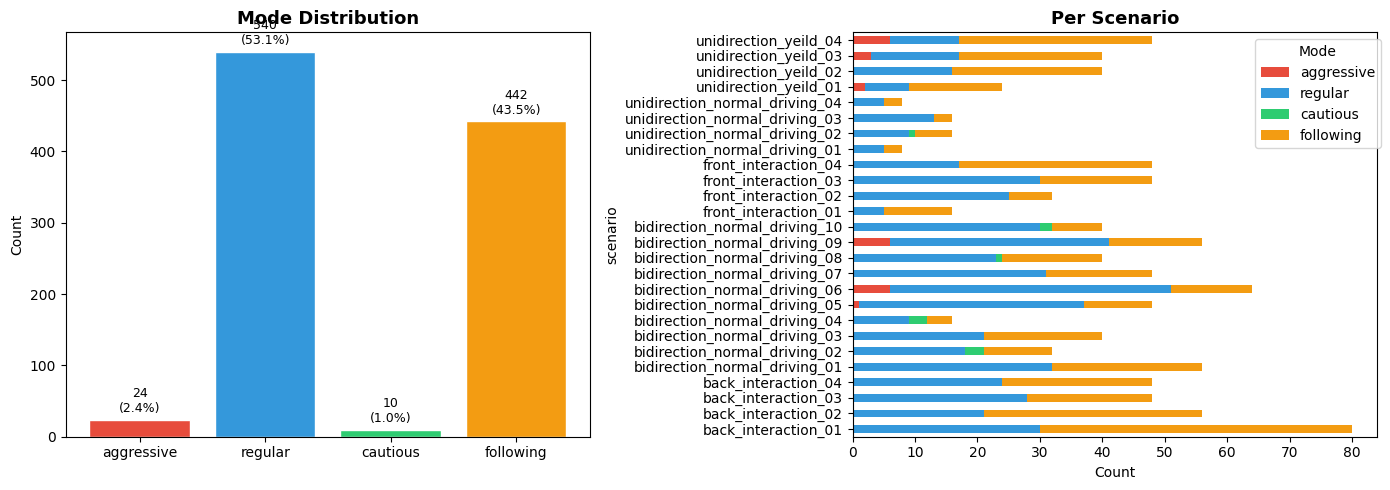

In [3]:
# Cell 3: Mode Distribution Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
dist = labels_df['mode_name'].value_counts().reindex(MODE_NAMES, fill_value=0)
colors = [MODE_COLORS[i] for i in range(NUM_MODES)]
axes[0].bar(dist.index, dist.values, color=colors, edgecolor='white')
axes[0].set_title('Mode Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, (name, count) in enumerate(zip(dist.index, dist.values)):
    axes[0].text(i, count + max(dist.values)*0.02,
                f'{count}\n({100*count/max(len(labels_df),1):.1f}%)',
                ha='center', fontsize=9)

# Per-scenario breakdown
if 'scenario' in labels_df.columns:
    sc = labels_df.groupby(['scenario', 'mode_name']).size().unstack(fill_value=0)
    sc = sc.reindex(columns=MODE_NAMES, fill_value=0)
    sc.plot(kind='barh', stacked=True, ax=axes[1],
            color=[MODE_COLORS[i] for i in range(NUM_MODES)])
    axes[1].set_title('Per Scenario', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Count')
    axes[1].legend(title='Mode', bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

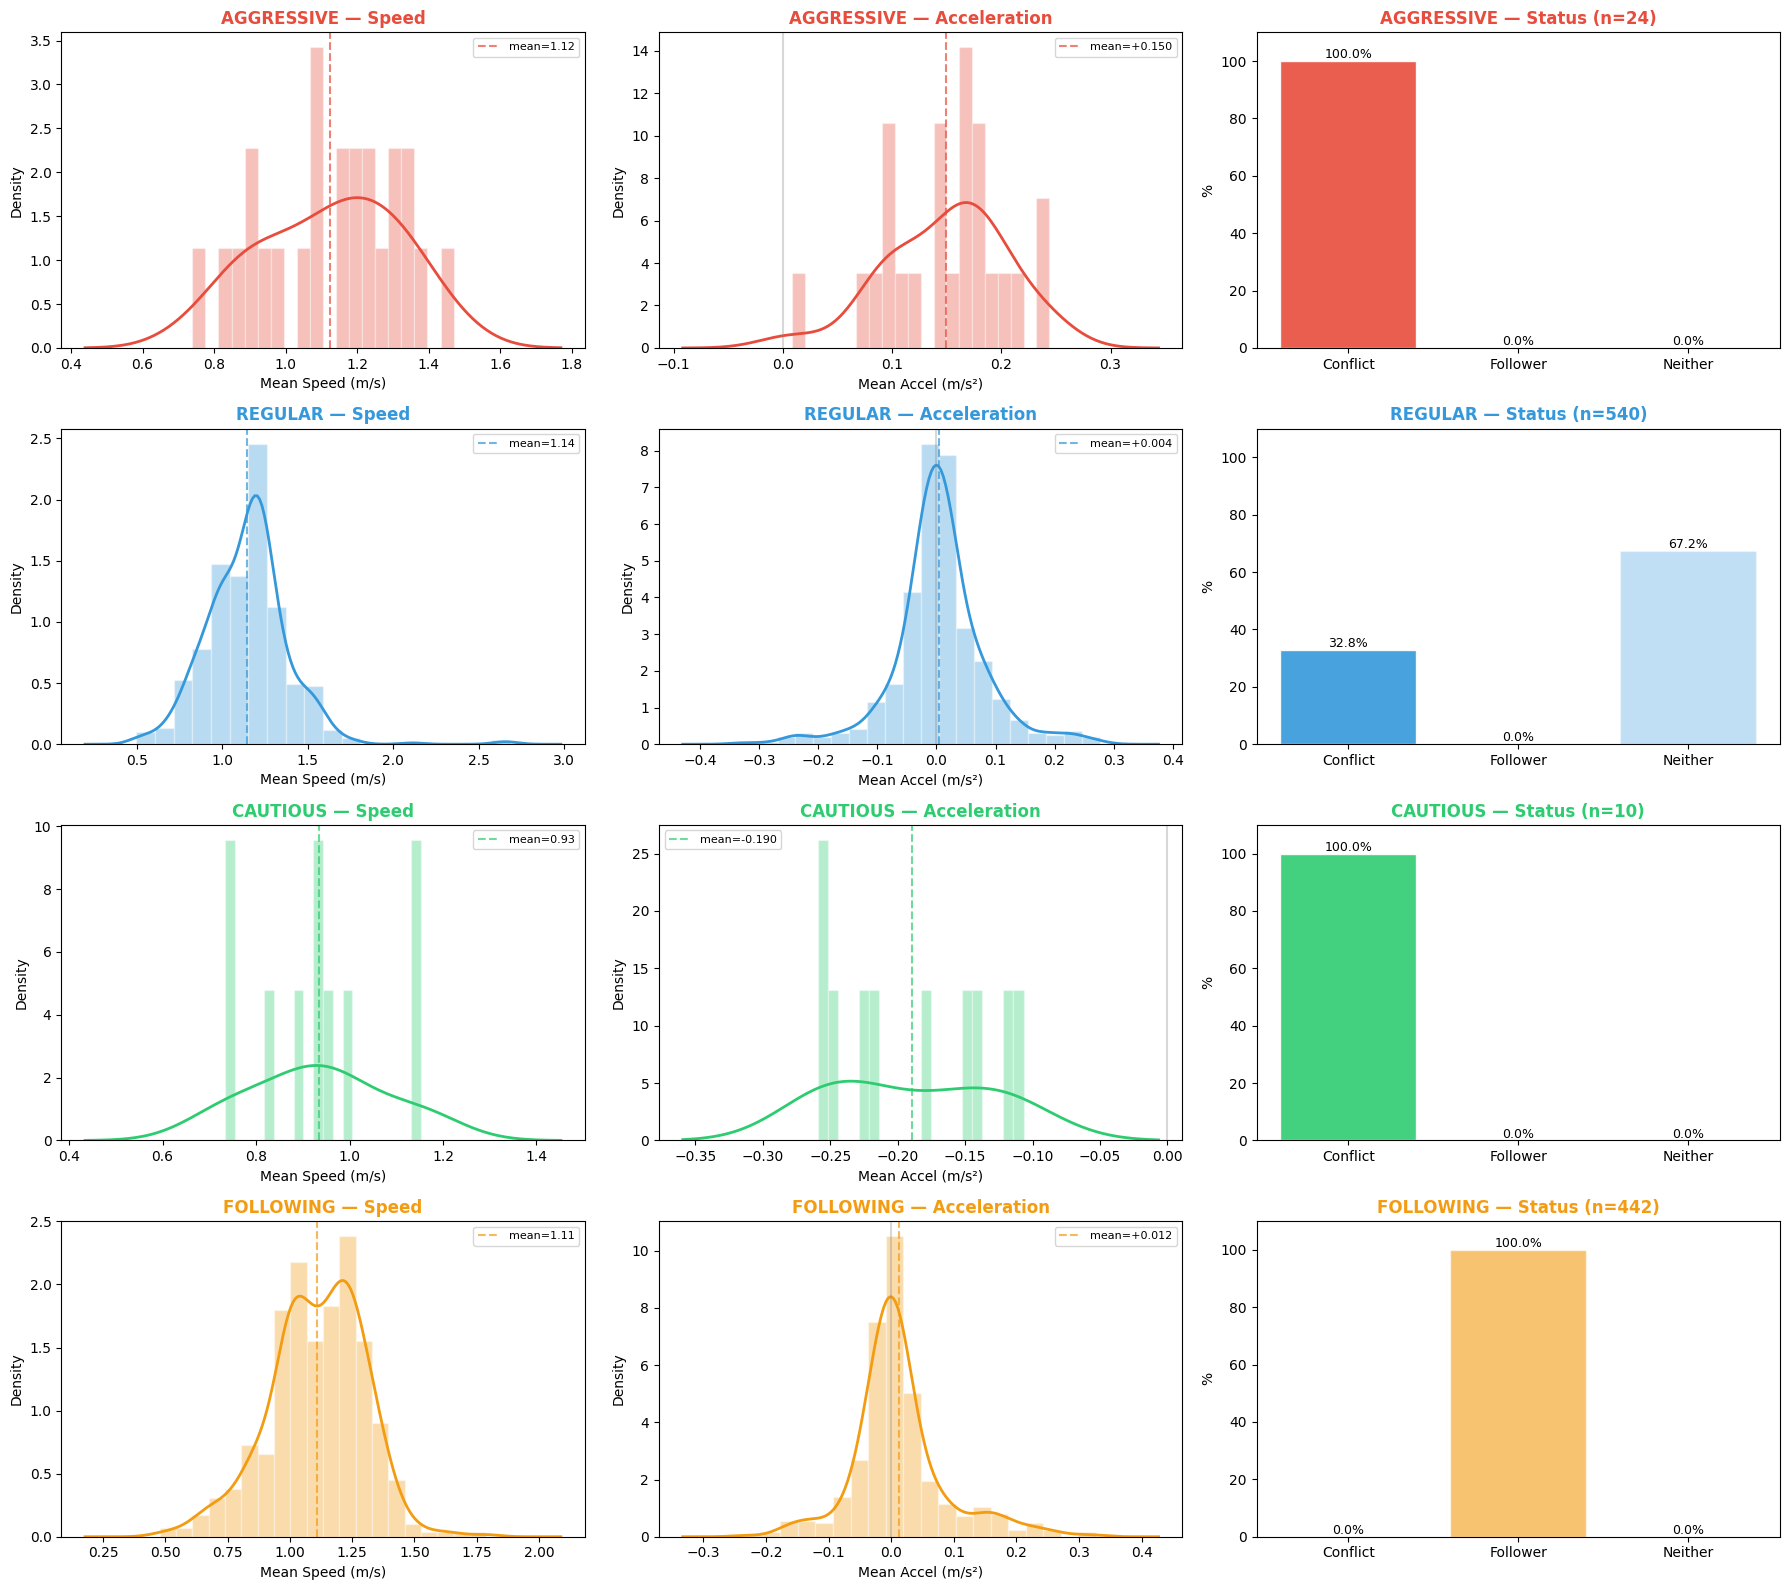

In [4]:
#Feature Statistics — Speed & Acceleration by Mode (Separated + KDE)
from scipy.stats import gaussian_kde
 
fig, axes = plt.subplots(NUM_MODES, 3, figsize=(18, 4 * NUM_MODES))
 
for mode_id, mode_name in enumerate(MODE_NAMES):
    subset = labels_df[labels_df['mode'] == mode_id]
    color = MODE_COLORS[mode_id]
    row = axes[mode_id]
 
    # --- Speed ---
    ax_spd = row[0]
    if not subset.empty and subset['mean_speed'].std() > 1e-6:
        speeds = subset['mean_speed'].dropna().values
        ax_spd.hist(speeds, bins=20, alpha=0.35, color=color, density=True, edgecolor='white')
        # KDE (Gaussian regression line)
        xs = np.linspace(speeds.min() - 0.3, speeds.max() + 0.3, 200)
        kde = gaussian_kde(speeds)
        ax_spd.plot(xs, kde(xs), color=color, linewidth=2)
        ax_spd.axvline(x=np.mean(speeds), color=color, linestyle='--', alpha=0.7,
                       label=f'mean={np.mean(speeds):.2f}')
    ax_spd.set_title(f'{mode_name.upper()} — Speed', fontweight='bold', color=color)
    ax_spd.set_xlabel('Mean Speed (m/s)')
    ax_spd.set_ylabel('Density')
    ax_spd.legend(fontsize=8)
 
    # --- Acceleration ---
    ax_acc = row[1]
    if not subset.empty and subset['mean_accel'].std() > 1e-6:
        accels = subset['mean_accel'].dropna().values
        ax_acc.hist(accels, bins=20, alpha=0.35, color=color, density=True, edgecolor='white')
        xs = np.linspace(accels.min() - 0.1, accels.max() + 0.1, 200)
        kde = gaussian_kde(accels)
        ax_acc.plot(xs, kde(xs), color=color, linewidth=2)
        ax_acc.axvline(x=np.mean(accels), color=color, linestyle='--', alpha=0.7,
                       label=f'mean={np.mean(accels):+.3f}')
        ax_acc.axvline(x=0, color='gray', linestyle='-', alpha=0.3)
    ax_acc.set_title(f'{mode_name.upper()} — Acceleration', fontweight='bold', color=color)
    ax_acc.set_xlabel('Mean Accel (m/s²)')
    ax_acc.set_ylabel('Density')
    ax_acc.legend(fontsize=8)
 
    # --- Conflict & Follower rates ---
    # --- Conflict & Follower rates ---
    ax_bar = row[2]
    n_total = len(subset)
    if n_total > 0:
        conflict_pct = subset['has_conflict'].mean() * 100
        follower_pct = subset['is_follower'].mean() * 100
        normal_pct = 100 - conflict_pct - follower_pct
    else:
        conflict_pct = follower_pct = normal_pct = 0

    bar_vals = [conflict_pct, follower_pct, max(normal_pct, 0)]
    bar_alphas = [0.9, 0.6, 0.3]
    for j, (label, val, a) in enumerate(zip(['Conflict', 'Follower', 'Neither'], bar_vals, bar_alphas)):
        ax_bar.bar(label, val, color=color, alpha=a, edgecolor='white')
        ax_bar.text(j, val + 1, f'{val:.1f}%', ha='center', fontsize=9)
    ax_bar.set_title(f'{mode_name.upper()} — Status (n={n_total})', fontweight='bold', color=color)
    ax_bar.set_ylabel('%')
    ax_bar.set_ylim(0, 110)
 
plt.tight_layout()
plt.show()

In [5]:
# Cell: Diagnostic — Why no Cautious labels?
#
# Paste this into your notebook AFTER Cell 2 (labels_df exists).
# It checks every conflict window and reports which of the 4 Cautious conditions fails.

print('=' * 70)
print('CAUTIOUS DIAGNOSTIC: checking all conflict windows')
print('=' * 70)

conflict_windows = labels_df[labels_df['has_conflict'] == True]
print(f'\nTotal windows with has_conflict=True: {len(conflict_windows)}')

if len(conflict_windows) == 0:
    print('\n*** NO CONFLICT WINDOWS AT ALL ***')
    print('Problem is at Level 1: track_ttc_evolution() never finds conflict.')
    print('Check:')
    print('  - Are vehicle CSV files being loaded? (veh_data not empty)')
    print('  - Does compute_ttc() ever return conflict=True?')
    print('  - Is conflict_frame_count >= 2? (the minimum threshold)')
else:
    # Check each condition for conflict windows
    has_diag = 'delta_ttc_init' in labels_df.columns
    
    if not has_diag:
        print('\n*** Diagnostic columns missing (delta_ttc_init, ttc_ped_min, ttc_veh_min) ***')
        print('Are you using the NEW pseudo_labeler.py? The old one does not output these.')
        print('Make sure to restart kernel and reimport after replacing the file.')
    else:
        print(f'\n--- Condition breakdown for {len(conflict_windows)} conflict windows ---\n')
        
        # Condition 2: ΔTTC_init < 0 (ped advantaged)
        valid_delta = conflict_windows['delta_ttc_init'].notna()
        cond2 = conflict_windows.loc[valid_delta, 'delta_ttc_init'] < 0
        n_cond2 = cond2.sum()
        print(f'Cond 2: ΔTTC_init < 0 (ped advantaged):  {n_cond2}/{len(conflict_windows)}')
        if n_cond2 > 0:
            vals = conflict_windows.loc[valid_delta & cond2, 'delta_ttc_init']
            print(f'         range: [{vals.min():.3f}, {vals.max():.3f}]')
        
        # Show ΔTTC_init distribution
        delta_vals = conflict_windows.loc[valid_delta, 'delta_ttc_init']
        print(f'\n  ΔTTC_init distribution (all conflict windows):')
        print(f'    min={delta_vals.min():.3f}, median={delta_vals.median():.3f}, '
              f'max={delta_vals.max():.3f}, mean={delta_vals.mean():.3f}')
        
        # Condition 3: mean_accel < -0.3
        cond3 = conflict_windows['mean_accel'] < -0.1
        n_cond3 = cond3.sum()
        print(f'\nCond 3: mean_accel < -0.3 (sig decel):  {n_cond3}/{len(conflict_windows)}')
        if n_cond3 > 0:
            vals = conflict_windows.loc[cond3, 'mean_accel']
            print(f'         range: [{vals.min():.3f}, {vals.max():.3f}]')
        
        print(f'\n  mean_accel distribution (all conflict windows):')
        print(f'    min={conflict_windows["mean_accel"].min():.3f}, '
              f'median={conflict_windows["mean_accel"].median():.3f}, '
              f'mean={conflict_windows["mean_accel"].mean():.3f}, '
              f'max={conflict_windows["mean_accel"].max():.3f}')
        
        # Condition 4a: ttc_veh_min < 0.5 (vehicle converges to 0)
        cond4a = conflict_windows['ttc_veh_min'] < 0.5
        n_cond4a = cond4a.sum()
        print(f'\nCond 4a: ttc_veh_min < 0.5 (veh→0):    {n_cond4a}/{len(conflict_windows)}')
        if n_cond4a > 0:
            vals = conflict_windows.loc[cond4a, 'ttc_veh_min']
            print(f'          range: [{vals.min():.3f}, {vals.max():.3f}]')
        
        print(f'\n  ttc_veh_min distribution (all conflict windows):')
        tv = conflict_windows['ttc_veh_min']
        tv_finite = tv[tv < 1e6]
        if len(tv_finite) > 0:
            print(f'    min={tv_finite.min():.3f}, median={tv_finite.median():.3f}, '
                  f'max={tv_finite.max():.3f}')
        else:
            print(f'    ALL inf (no valid TTC_veh convergence data)')
        
        # Condition 4b: ttc_ped_min > 0.5 (ped stays away)
        cond4b = conflict_windows['ttc_ped_min'] > 0.5
        n_cond4b = cond4b.sum()
        print(f'\nCond 4b: ttc_ped_min > 0.5 (ped stays): {n_cond4b}/{len(conflict_windows)}')
        
        print(f'\n  ttc_ped_min distribution (all conflict windows):')
        tp = conflict_windows['ttc_ped_min']
        tp_finite = tp[tp < 1e6]
        if len(tp_finite) > 0:
            print(f'    min={tp_finite.min():.3f}, median={tp_finite.median():.3f}, '
                  f'max={tp_finite.max():.3f}')
        
        # Combined: how many pass ALL 4 conditions?
        all_cond = valid_delta & cond2 & cond3 & cond4a & cond4b
        n_all = all_cond.sum()
        print(f'\n--- ALL 4 conditions met (would be Cautious): {n_all}/{len(conflict_windows)} ---')
        
        # Partial passes
        c2_and_c3 = (valid_delta & cond2 & cond3).sum()
        c2_and_c4 = (valid_delta & cond2 & cond4a & cond4b).sum()
        c3_and_c4 = (cond3 & cond4a & cond4b).sum()
        print(f'\n  Partial combinations:')
        print(f'    Cond2 + Cond3 (advantaged + decel):     {c2_and_c3}')
        print(f'    Cond2 + Cond4 (advantaged + veh wins):  {c2_and_c4}')
        print(f'    Cond3 + Cond4 (decel + veh wins):       {c3_and_c4}')
        
        # Show nearest misses
        if n_all == 0 and c2_and_c3 > 0:
            print(f'\n*** LIKELY BOTTLENECK: Condition 4 (convergence) ***')
            subset = conflict_windows[valid_delta & cond2 & cond3]
            print(f'    Windows passing Cond2+3 but failing Cond4:')
            print(f'    ttc_veh_min: min={subset["ttc_veh_min"].min():.3f}, '
                  f'median={subset["ttc_veh_min"].median():.3f}')
            print(f'    ttc_ped_min: min={subset["ttc_ped_min"].min():.3f}, '
                  f'median={subset["ttc_ped_min"].median():.3f}')
            print(f'\n    → Consider raising ttc_convergence (currently 0.5)')
            print(f'    → Or lowering ttc_remaining_min (currently 0.5)')
        
        if n_all == 0 and c2_and_c4 > 0:
            print(f'\n*** LIKELY BOTTLENECK: Condition 3 (deceleration) ***')
            subset = conflict_windows[valid_delta & cond2 & cond4a & cond4b]
            print(f'    Windows passing Cond2+4 but failing Cond3:')
            print(f'    mean_accel: min={subset["mean_accel"].min():.3f}, '
                  f'max={subset["mean_accel"].max():.3f}')
            print(f'\n    → Consider raising decel_threshold (currently -0.3)')
        
        if len(conflict_windows) > 0 and n_cond2 == 0:
            print(f'\n*** LIKELY BOTTLENECK: Condition 2 (initial stance) ***')
            print(f'    No windows have ΔTTC_init < 0')
            print(f'    All conflict windows have ped arriving AFTER vehicle')
            print(f'    → Check if TTC sampling captures the early phase of conflict')

print('\n' + '=' * 70)

CAUTIOUS DIAGNOSTIC: checking all conflict windows

Total windows with has_conflict=True: 211

--- Condition breakdown for 211 conflict windows ---

Cond 2: ΔTTC_init < 0 (ped advantaged):  158/211
         range: [-23.995, -0.008]

  ΔTTC_init distribution (all conflict windows):
    min=-23.995, median=-1.563, max=17.285, mean=-2.150

Cond 3: mean_accel < -0.3 (sig decel):  27/211
         range: [-0.330, -0.102]

  mean_accel distribution (all conflict windows):
    min=-0.330, median=0.012, mean=0.003, max=0.244

Cond 4a: ttc_veh_min < 0.5 (veh→0):    37/211
          range: [0.012, 0.500]

  ttc_veh_min distribution (all conflict windows):
    min=0.012, median=2.481, max=5.225

Cond 4b: ttc_ped_min > 0.5 (ped stays): 128/211

  ttc_ped_min distribution (all conflict windows):
    min=0.031, median=1.186, max=4.715

--- ALL 4 conditions met (would be Cautious): 10/211 ---

  Partial combinations:
    Cond2 + Cond3 (advantaged + decel):     26
    Cond2 + Cond4 (advantaged + veh wi

In [6]:
# Cell 5: Trajectory Visualization with Mode Labels
#
# Same plotting style as your GA notebook cells 6-7:
#   - Ground truth: green dashed
#   - Vehicle: blue
#   - Pedestrians: colored by MODE

def load_scenario_data(scenario_name):
    """Load ped+veh CSV pair for a scenario (same logic as GA notebook)."""
    ped_file, veh_file = None, None
    for f in all_files:
        if f.split('_traj_')[0] == scenario_name:
            if '_ped_' in f: ped_file = f
            elif '_veh_' in f: veh_file = f
    
    ped_data = pd.read_csv(os.path.join(data_dir, ped_file)) if ped_file else pd.DataFrame()
    if 'x_est' in ped_data.columns:
        ped_data = ped_data.rename(columns={'x_est':'x','y_est':'y','vx_est':'vx','vy_est':'vy'})
    
    veh_data = pd.DataFrame()
    if veh_file:
        veh_data = pd.read_csv(os.path.join(data_dir, veh_file))
        if 'x_est' in veh_data.columns:
            veh_data = veh_data.rename(columns={'x_est':'x','y_est':'y','psi_est':'psi','vel_est':'vel'})
    
    return ped_data, veh_data, ped_file, veh_file


def plot_labeled_trajectories(scenario_name):
    """Plot trajectories colored by behavioral mode."""
    ped_data, veh_data, ped_file, veh_file = load_scenario_data(scenario_name)
    if ped_data.empty:
        print(f'Scenario not found: {scenario_name}')
        return
    
    # Get dominant mode per pedestrian
    # Priority: if ANY aggressive or cautious window exists, use that mode
    # If both exist, use whichever has more windows
    # Otherwise use overall dominant mode
    sc_labels = labels_df[labels_df['scenario'] == scenario_name] if 'scenario' in labels_df.columns else labels_df
    ped_modes = {}
    for pid in sc_labels['ped_id'].unique():
        pid_labels = sc_labels[sc_labels['ped_id'] == pid]
        mode_counts = pid_labels['mode'].value_counts()
        
        n_agg = mode_counts.get(0, 0)  # aggressive
        n_cau = mode_counts.get(2, 0)  # cautious
        
        if n_agg > 0 or n_cau > 0:
            # Has conflict-related labels → pick the one with more windows
            if n_agg >= n_cau:
                ped_modes[int(pid)] = 0  # aggressive
            else:
                ped_modes[int(pid)] = 2  # cautious
        else:
            # No aggressive/cautious → use overall dominant
            ped_modes[int(pid)] = int(mode_counts.index[0])
    
    plt.figure(figsize=(10, 10))
    
    for _, grp in ped_data.groupby('id'):
        plt.plot(grp['x'], grp['y'], '--', color='green', alpha=0.4)
    
    if not veh_data.empty:
        for _, grp in veh_data.groupby('id'):
            plt.plot(grp['x'], grp['y'], '-', color='blue', alpha=0.6, linewidth=2)
    
    for pid in ped_data['id'].unique():
        pdf = ped_data[ped_data['id'] == pid].sort_values('frame')
        mode = ped_modes.get(int(pid), 1)
        color = MODE_COLORS[mode]
        plt.plot(pdf['x'], pdf['y'], '-', color=color, alpha=0.8, linewidth=1.5)
        plt.plot(pdf['x'].iloc[0], pdf['y'].iloc[0], 'o', color=color, markersize=5)
        plt.plot(pdf['x'].iloc[-1], pdf['y'].iloc[-1], '^', color=color, markersize=5)
        mid = len(pdf)//2
        plt.annotate(f'P{pid}', (pdf['x'].iloc[mid], pdf['y'].iloc[mid]),
                    fontsize=7, color=color, fontweight='bold')
    
    handles = [Line2D([0],[0], color='green', linestyle='--', label='Ped GT')]
    if not veh_data.empty:
        handles.append(Line2D([0],[0], color='blue', linestyle='-', label='Vehicle'))
    for i in range(NUM_MODES):
        handles.append(Line2D([0],[0], color=MODE_COLORS[i], linestyle='-',
                              label=f'{MODE_LABELS[i]} ({i})'))
    plt.legend(handles=handles, bbox_to_anchor=(1.05, 1.0), borderaxespad=0.)
    
    plt.xlabel('X Position (m)')
    plt.ylabel('Y Position (m)')
    plt.title(f'{scenario_name} — Mode-Labeled Trajectories\n({ped_file} + {veh_file})')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    print(f'\nPedestrian mode assignments:')
    for pid, mode in sorted(ped_modes.items()):
        pl = sc_labels[sc_labels['ped_id'] == pid]
        n_agg = (pl['mode'] == 0).sum()
        n_cau = (pl['mode'] == 2).sum()
        n_total = len(pl)
        print(f'  P{pid:3d} -> {MODE_LABELS[mode]:12s} | '
              f'speed={pl["mean_speed"].mean():.2f} m/s | '
              f'conflict={pl["has_conflict"].mean()*100:.0f}% | '
              f'agg={n_agg}/{n_total} cau={n_cau}/{n_total}')

In [7]:
# Cell 6: Save labeled trajectory plots to disk
# save_dir = r'/Volumes/Seagate129/P2V_Interaction_Modeling/Figure/Campus_labelled'
save_dir = r'/Volumes/Seagate129/P2V_Interaction_Modeling/Figure/V2P_controlled'
os.makedirs(save_dir, exist_ok=True)

scenarios = labels_df['scenario'].unique() if 'scenario' in labels_df.columns else []
print(f'Scenarios to save: {len(scenarios)}')

for sc in scenarios:
    ped_data, veh_data, ped_file, veh_file = load_scenario_data(sc)
    if ped_data.empty:
        continue

    sc_labels = labels_df[labels_df['scenario'] == sc] if 'scenario' in labels_df.columns else labels_df
    ped_modes = {}
    for pid in sc_labels['ped_id'].unique():
        mode_counts = sc_labels[sc_labels['ped_id'] == pid]['mode'].value_counts()
        ped_modes[int(pid)] = int(mode_counts.index[0])

    fig, ax = plt.subplots(figsize=(10, 10))

    for _, grp in ped_data.groupby('id'):
        ax.plot(grp['x'], grp['y'], '--', color='green', alpha=0.4)

    if not veh_data.empty:
        for _, grp in veh_data.groupby('id'):
            ax.plot(grp['x'], grp['y'], '-', color='blue', alpha=0.6, linewidth=2)

    for pid in ped_data['id'].unique():
        pdf = ped_data[ped_data['id'] == pid].sort_values('frame')
        mode = ped_modes.get(int(pid), 1)
        color = MODE_COLORS[mode]
        ax.plot(pdf['x'], pdf['y'], '-', color=color, alpha=0.8, linewidth=1.5)
        ax.plot(pdf['x'].iloc[0], pdf['y'].iloc[0], 'o', color=color, markersize=5)
        ax.plot(pdf['x'].iloc[-1], pdf['y'].iloc[-1], '^', color=color, markersize=5)
        mid = len(pdf) // 2
        ax.annotate(f'P{pid}', (pdf['x'].iloc[mid], pdf['y'].iloc[mid]),
                    fontsize=7, color=color, fontweight='bold')

    handles = [Line2D([0],[0], color='green', linestyle='--', label='Ped GT')]
    if not veh_data.empty:
        handles.append(Line2D([0],[0], color='blue', linestyle='-', label='Vehicle'))
    for i in range(NUM_MODES):
        handles.append(Line2D([0],[0], color=MODE_COLORS[i], linestyle='-',
                              label=f'{MODE_LABELS[i]} ({i})'))
    ax.legend(handles=handles, bbox_to_anchor=(1.05, 1.0), borderaxespad=0.)
    ax.set_xlabel('X Position (m)')
    ax.set_ylabel('Y Position (m)')
    ax.set_title(f'{sc} — Mode-Labeled Trajectories')
    ax.grid(True, alpha=0.3)

    fig.savefig(os.path.join(save_dir, f'{sc}_labeled.png'), bbox_inches='tight', dpi=300)
    plt.close(fig)
    print(f'  Saved: {sc}_labeled.png')

print(f'\nAll {len(scenarios)} figures saved to {save_dir}')

Scenarios to save: 26
  Saved: back_interaction_04_labeled.png
  Saved: back_interaction_01_labeled.png
  Saved: back_interaction_02_labeled.png
  Saved: back_interaction_03_labeled.png
  Saved: front_interaction_04_labeled.png
  Saved: front_interaction_01_labeled.png
  Saved: front_interaction_02_labeled.png
  Saved: front_interaction_03_labeled.png
  Saved: bidirection_normal_driving_10_labeled.png
  Saved: bidirection_normal_driving_01_labeled.png
  Saved: bidirection_normal_driving_02_labeled.png
  Saved: bidirection_normal_driving_03_labeled.png
  Saved: bidirection_normal_driving_04_labeled.png
  Saved: bidirection_normal_driving_05_labeled.png
  Saved: bidirection_normal_driving_06_labeled.png
  Saved: bidirection_normal_driving_07_labeled.png
  Saved: bidirection_normal_driving_08_labeled.png
  Saved: bidirection_normal_driving_09_labeled.png
  Saved: unidirection_yeild_04_labeled.png
  Saved: unidirection_normal_driving_01_labeled.png
  Saved: unidirection_normal_driving_02_l

In [8]:
# Cell 7: Pedestrian Timeline (5-panel verification)
#
# Panels: Speed | Acceleration | TTC with Vehicles | Heading Change | Mode Bar
# Updated for new pseudo_labeler v2 with game-theoretic diagnostics.
#
# Usage:
#   plot_ped_timeline_enhanced('intersection_04', ped_id=5)

import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

def plot_ped_timeline(scenario_name, ped_id, 
                                labels_df=labels_df, 
                                fps=30.0, ttc_cap=5.0):
    """
    Enhanced 5-panel timeline for a single pedestrian.
    
    Panels:
      1. Speed (m/s) with v_des reference
      2. Acceleration (m/s²) with agg/cau thresholds
      3. TTC with vehicles (solid=TTC_ped, dashed=TTC_veh, shaded=ΔTTC)
      4. Heading change (°/frame) with turn threshold
      5. Mode bar (colored by behavioral mode)
    """
    ped_data, veh_data, ped_file, veh_file = load_scenario_data(scenario_name)
    if ped_data.empty:
        print(f'Scenario not found: {scenario_name}')
        return
    
    pdf = ped_data[ped_data['id'] == ped_id].sort_values('frame')
    if pdf.empty:
        print(f'Pedestrian {ped_id} not found in {scenario_name}')
        return
    
    dt = 1.0 / fps
    frames = pdf['frame'].values
    speed = np.sqrt(pdf['vx'].values**2 + pdf['vy'].values**2)
    
    # Acceleration
    accel = np.zeros_like(speed)
    accel[1:] = np.diff(speed) / dt
    
    # Heading and heading change
    heading = np.degrees(np.arctan2(pdf['vy'].values, pdf['vx'].values))
    heading_change = np.zeros_like(heading)
    heading_change[1:] = np.diff(heading)
    # Wrap to [-180, 180]
    heading_change = (heading_change + 180) % 360 - 180
    
    # Get labels for this pedestrian
    if 'scenario' in labels_df.columns:
        sc_labels = labels_df[
            (labels_df['scenario'] == scenario_name) & 
            (labels_df['ped_id'] == ped_id)
        ].sort_values('frame_start')
    else:
        sc_labels = labels_df[
            labels_df['ped_id'] == ped_id
        ].sort_values('frame_start')
    
    # ---- Compute per-frame TTC with all vehicles ----
    ttc_data = {}  # {veh_id: {'frames': [], 'ttc_ped': [], 'ttc_veh': []}}
    
    if not veh_data.empty:
        # Precompute vehicle vx, vy if needed
        veh = veh_data.copy()
        if 'veh_vx' not in veh.columns and 'psi' in veh.columns:
            veh['veh_vx'] = veh['vel'] * np.cos(veh['psi'])
            veh['veh_vy'] = veh['vel'] * np.sin(veh['psi'])
        
        veh_ids = veh['id'].unique()
        
        for vid in veh_ids:
            vdf = veh[veh['id'] == vid].sort_values('frame')
            ttc_frames = []
            ttc_ped_vals = []
            ttc_veh_vals = []
            
            for f in frames:
                # Find vehicle at this frame (±2 frame tolerance)
                veh_at_f = vdf[(vdf['frame'] >= f - 2) & (vdf['frame'] <= f + 2)]
                if veh_at_f.empty:
                    continue
                if 'veh_vx' not in veh_at_f.columns:
                    continue
                    
                vrow = veh_at_f.iloc[len(veh_at_f) // 2]
                prow = pdf[pdf['frame'] == f]
                if prow.empty:
                    continue
                prow = prow.iloc[0]
                
                p_ped = np.array([prow['x'], prow['y']])
                v_ped = np.array([prow['vx'], prow['vy']])
                p_veh = np.array([vrow['x'], vrow['y']])
                v_veh = np.array([vrow['veh_vx'], vrow['veh_vy']])
                
                # Solve TTC system
                A = np.column_stack((v_ped, -v_veh))
                b = p_veh - p_ped
                
                if np.linalg.matrix_rank(A) < 2:
                    continue
                try:
                    Tp, Tv = np.linalg.solve(A, b)
                except np.linalg.LinAlgError:
                    continue
                
                # Only record valid positive TTCs
                if Tp > 0 and Tv > 0 and Tp < ttc_cap * 2 and Tv < ttc_cap * 2:
                    ttc_frames.append(f)
                    ttc_ped_vals.append(min(Tp, ttc_cap))
                    ttc_veh_vals.append(min(Tv, ttc_cap))
            
            if len(ttc_frames) > 5:
                ttc_data[vid] = {
                    'frames': np.array(ttc_frames),
                    'ttc_ped': np.array(ttc_ped_vals),
                    'ttc_veh': np.array(ttc_veh_vals),
                }
    
    # ---- Plotting ----
    fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=True,
                              gridspec_kw={'height_ratios': [3, 3, 3, 2, 1]})
    
    # Color config
    MODE_COLORS = {0: '#E74C3C', 1: '#3498DB', 2: '#2ECC71', 3: '#F39C12'}
    MODE_LABELS_MAP = {0: 'Aggressive', 1: 'Regular', 2: 'Cautious', 3: 'Following'}
    
    # Apply mode-colored background spans to all panels
    for _, row in sc_labels.iterrows():
        mode = int(row['mode'])
        color = MODE_COLORS[mode]
        for ax in axes[:4]:  # panels 0-3
            ax.axvspan(row['frame_start'], row['frame_end'],
                       alpha=0.12, color=color)
    
    # ---- Panel 0: Speed ----
    ax = axes[0]
    ax.plot(frames, speed, 'k-', linewidth=1.5, label='Speed')
    ax.axhline(y=1.44, color='gray', linestyle=':', alpha=0.5, 
               linewidth=1, label='v_des=1.44')
    ax.set_ylabel('Speed (m/s)')
    ax.set_title(f'P{ped_id} in {scenario_name} — Enhanced Timeline',
                 fontsize=13, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    
    # Mark conflict windows with ⚠
    for _, row in sc_labels[sc_labels['has_conflict'] == True].iterrows():
        mid = (row['frame_start'] + row['frame_end']) / 2
        ax.annotate('\u26A0', (mid, speed.max() * 0.97),
                    fontsize=10, ha='center', color='red', alpha=0.7)
    
    # ---- Panel 1: Acceleration ----
    ax = axes[1]
    ax.plot(frames, accel, 'k-', linewidth=0.8)
    ax.axhline(y=0.3, color='red', linestyle=':', alpha=0.5,
               linewidth=1, label='Agg thresh (+0.3)')
    ax.axhline(y=-0.3, color='green', linestyle=':', alpha=0.5,
               linewidth=1, label='Cau thresh (-0.3)')
    ax.axhline(y=0, color='gray', linestyle='-', alpha=0.2)
    ax.set_ylabel('Accel (m/s²)')
    ax.legend(loc='upper right', fontsize=8)
    
    # ---- Panel 2: TTC with Vehicles ----
    ax = axes[2]
    
    if ttc_data:
        colors_ttc = ['red', 'purple', 'brown', 'darkblue']
        for i, (vid, td) in enumerate(ttc_data.items()):
            c = colors_ttc[i % len(colors_ttc)]
            label_p = f'V{vid} TTC_ped'
            label_v = f'V{vid} TTC_veh'
            
            ax.plot(td['frames'], td['ttc_ped'], '-', color=c,
                    linewidth=1.5, label=label_p)
            ax.plot(td['frames'], td['ttc_veh'], '--', color=c,
                    linewidth=1.2, alpha=0.7, label=label_v)
            
            # Shade ΔTTC region between the two curves
            ax.fill_between(td['frames'], td['ttc_ped'], td['ttc_veh'],
                           alpha=0.08, color=c)
        
        ax.set_ylim(0, ttc_cap)
        ax.legend(loc='upper right', fontsize=7)
    else:
        ax.text(0.5, 0.5, 'No vehicle TTC data', transform=ax.transAxes,
                ha='center', va='center', fontsize=12, color='gray', alpha=0.5)
    
    ax.set_ylabel('TTC (s)')
    ax.set_title('TTC with Vehicles (solid=TTC_ped, dashed=TTC_veh, shaded=ΔTTC)',
                 fontsize=9, color='gray', loc='center')
    
    # ---- Panel 3: Heading Change ----
    ax = axes[3]
    ax.plot(frames, heading_change, 'k-', linewidth=0.8)
    ax.axhline(y=15, color='orange', linestyle=':', alpha=0.4,
               linewidth=1, label='Turn thresh (±15°)')
    ax.axhline(y=-15, color='orange', linestyle=':', alpha=0.4, linewidth=1)
    ax.set_ylabel('Heading Change (°/frame)')
    ax.legend(loc='upper right', fontsize=8)
    
    # ---- Panel 4: Mode Bar ----
    ax = axes[4]
    for _, row in sc_labels.iterrows():
        mode = int(row['mode'])
        ax.barh(0, row['frame_end'] - row['frame_start'],
                left=row['frame_start'], height=0.8,
                color=MODE_COLORS[mode], edgecolor='white', linewidth=0.5)
    
    ax.set_ylabel('Mode')
    ax.set_xlabel('Frame')
    ax.set_yticks([])
    ax.legend(handles=[mpatches.Patch(color=MODE_COLORS[i], label=MODE_LABELS_MAP[i])
                       for i in range(4)], ncol=4, loc='upper right', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # ---- Print window details ----
    print(f'\nWindow labels for P{ped_id}:')
    header = (f'  {"Start":>5s}-{"End":>5s} | {"Mode":12s} | {"Conf":4s} | '
              f'{"Speed":>6s} | {"Accel":>7s}')
    
    # Add new diagnostic columns if available
    has_diag = 'delta_ttc_init' in sc_labels.columns
    if has_diag:
        header += f' | {"ΔTTC_i":>7s} | {"Tp_min":>6s} | {"Tv_min":>6s}'
    
    print(header)
    print('  ' + '-' * len(header))
    
    for _, row in sc_labels.iterrows():
        line = (f'  {int(row["frame_start"]):5d}-{int(row["frame_end"]):5d} | '
                f'{MODE_LABELS_MAP[int(row["mode"])]:12s} | '
                f'{"Yes" if row["has_conflict"] else "No":4s} | '
                f'{row["mean_speed"]:6.3f} | '
                f'{row["mean_accel"]:+7.3f}')
        
        if has_diag:
            dttc = row.get('delta_ttc_init')
            tp = row.get('ttc_ped_min', float('inf'))
            tv = row.get('ttc_veh_min', float('inf'))
            dttc_str = f'{dttc:+7.2f}' if dttc is not None and not np.isinf(dttc) else '    N/A'
            tp_str = f'{tp:6.2f}' if not np.isinf(tp) else '   inf'
            tv_str = f'{tv:6.2f}' if not np.isinf(tv) else '   inf'
            line += f' | {dttc_str} | {tp_str} | {tv_str}'
        
        print(line)


===== AGGRESSIVE example: P1 in bidirection_normal_driving_05 =====


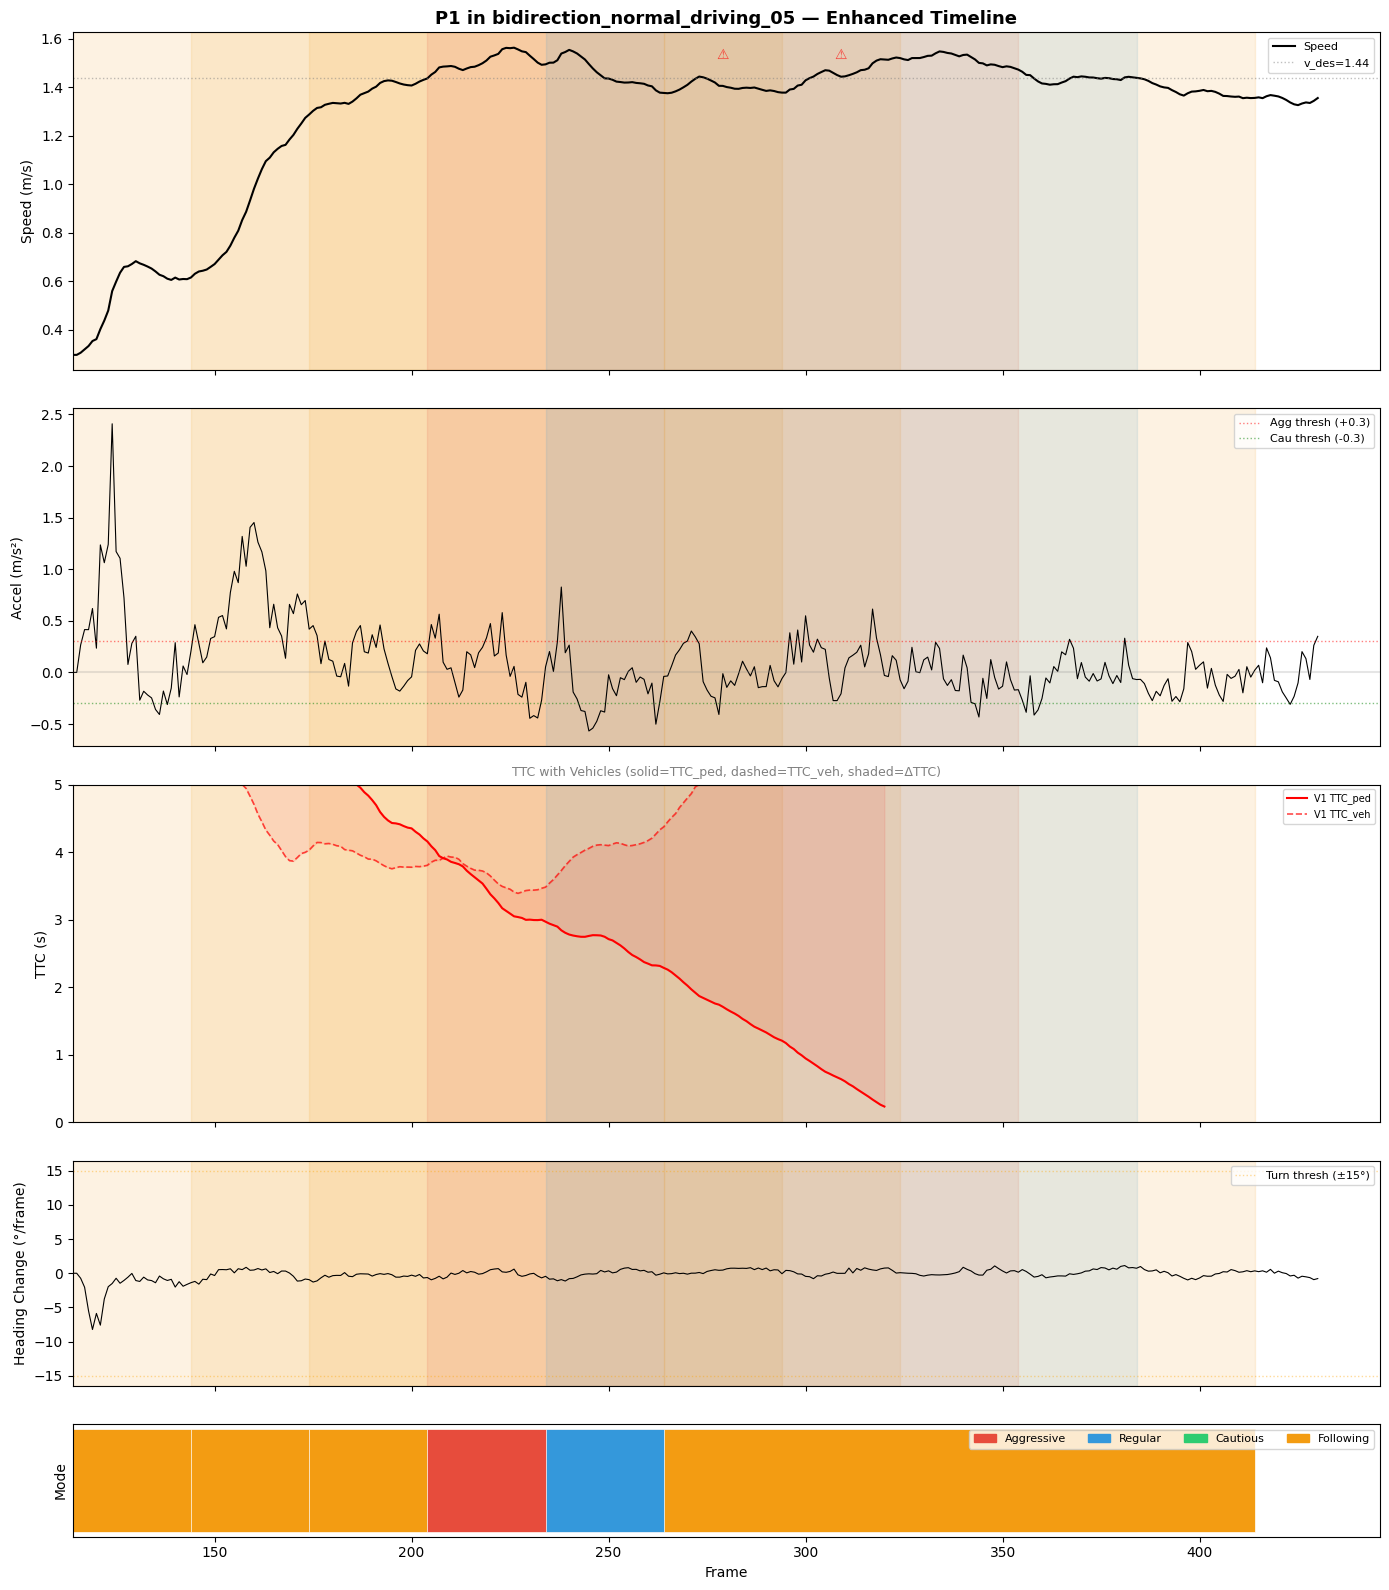


Window labels for P1:
  Start-  End | Mode         | Conf |  Speed |   Accel |  ΔTTC_i | Tp_min | Tv_min
  ----------------------------------------------------------------------------------
    114-  264 | Following    | No   |  1.162 |  +0.218 |    +nan |    inf |    inf
    144-  294 | Following    | No   |  1.334 |  +0.154 |    +nan |    inf |    inf
    174-  324 | Following    | No   |  1.441 |  +0.047 |    +nan |    inf |    inf
    204-  354 | Aggressive   | Yes  |  1.470 |  +0.008 |   +0.35 |   0.10 |   3.48
    234-  384 | Regular      | Yes  |  1.455 |  -0.011 |   -0.51 |   0.10 |   3.48
    264-  414 | Following    | No   |  1.440 |  -0.004 |    +nan |    inf |    inf

===== REGULAR example: P1 in back_interaction_04 =====


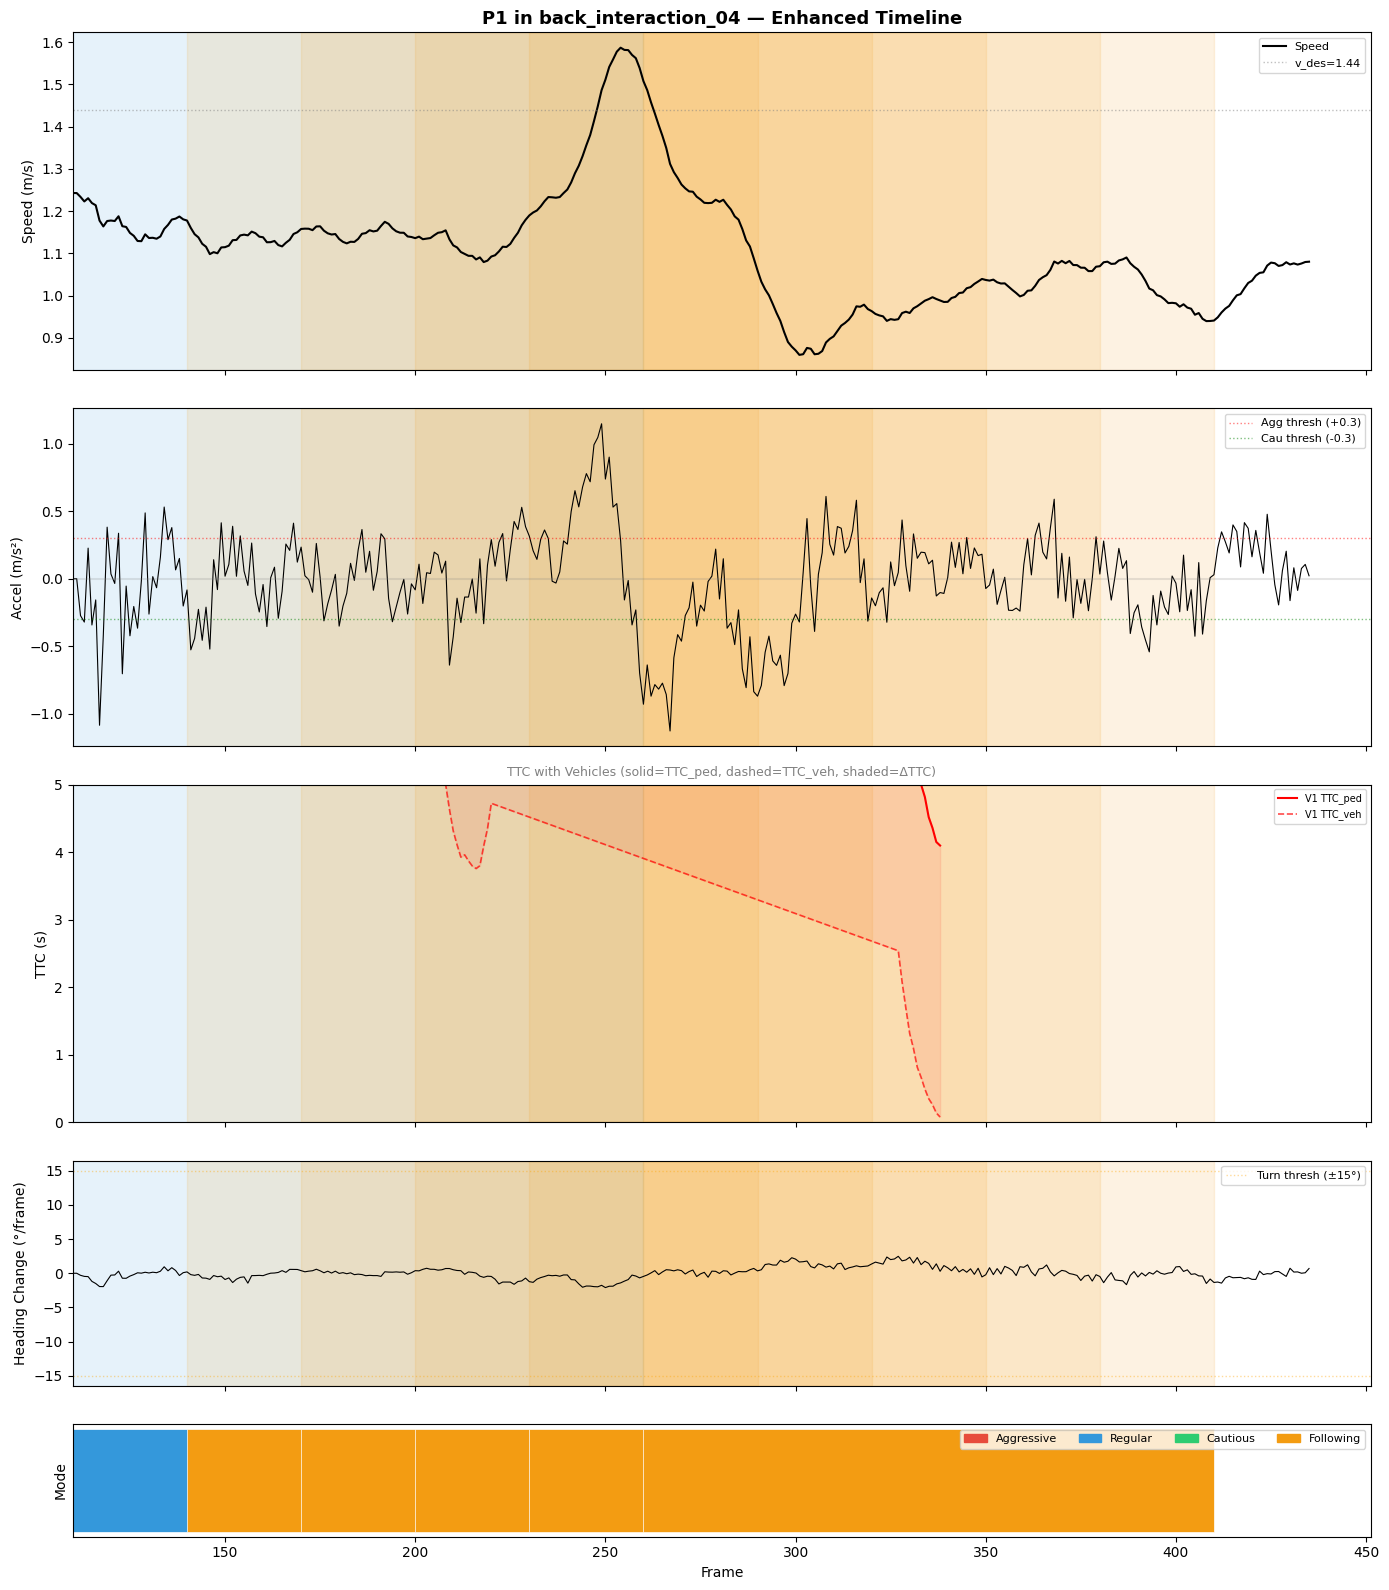


Window labels for P1:
  Start-  End | Mode         | Conf |  Speed |   Accel |  ΔTTC_i | Tp_min | Tv_min
  ----------------------------------------------------------------------------------
    110-  260 | Regular      | No   |  1.191 |  +0.060 |    +nan |    inf |    inf
    140-  290 | Following    | No   |  1.209 |  -0.018 |    +nan |    inf |    inf
    170-  320 | Following    | No   |  1.169 |  -0.038 |    +nan |    inf |    inf
    200-  350 | Following    | No   |  1.135 |  -0.019 |    +nan |    inf |    inf
    230-  380 | Following    | No   |  1.120 |  -0.024 |    +nan |    inf |    inf
    260-  410 | Following    | No   |  1.048 |  -0.114 |    +nan |    inf |    inf

===== CAUTIOUS example: P1 in bidirection_normal_driving_10 =====


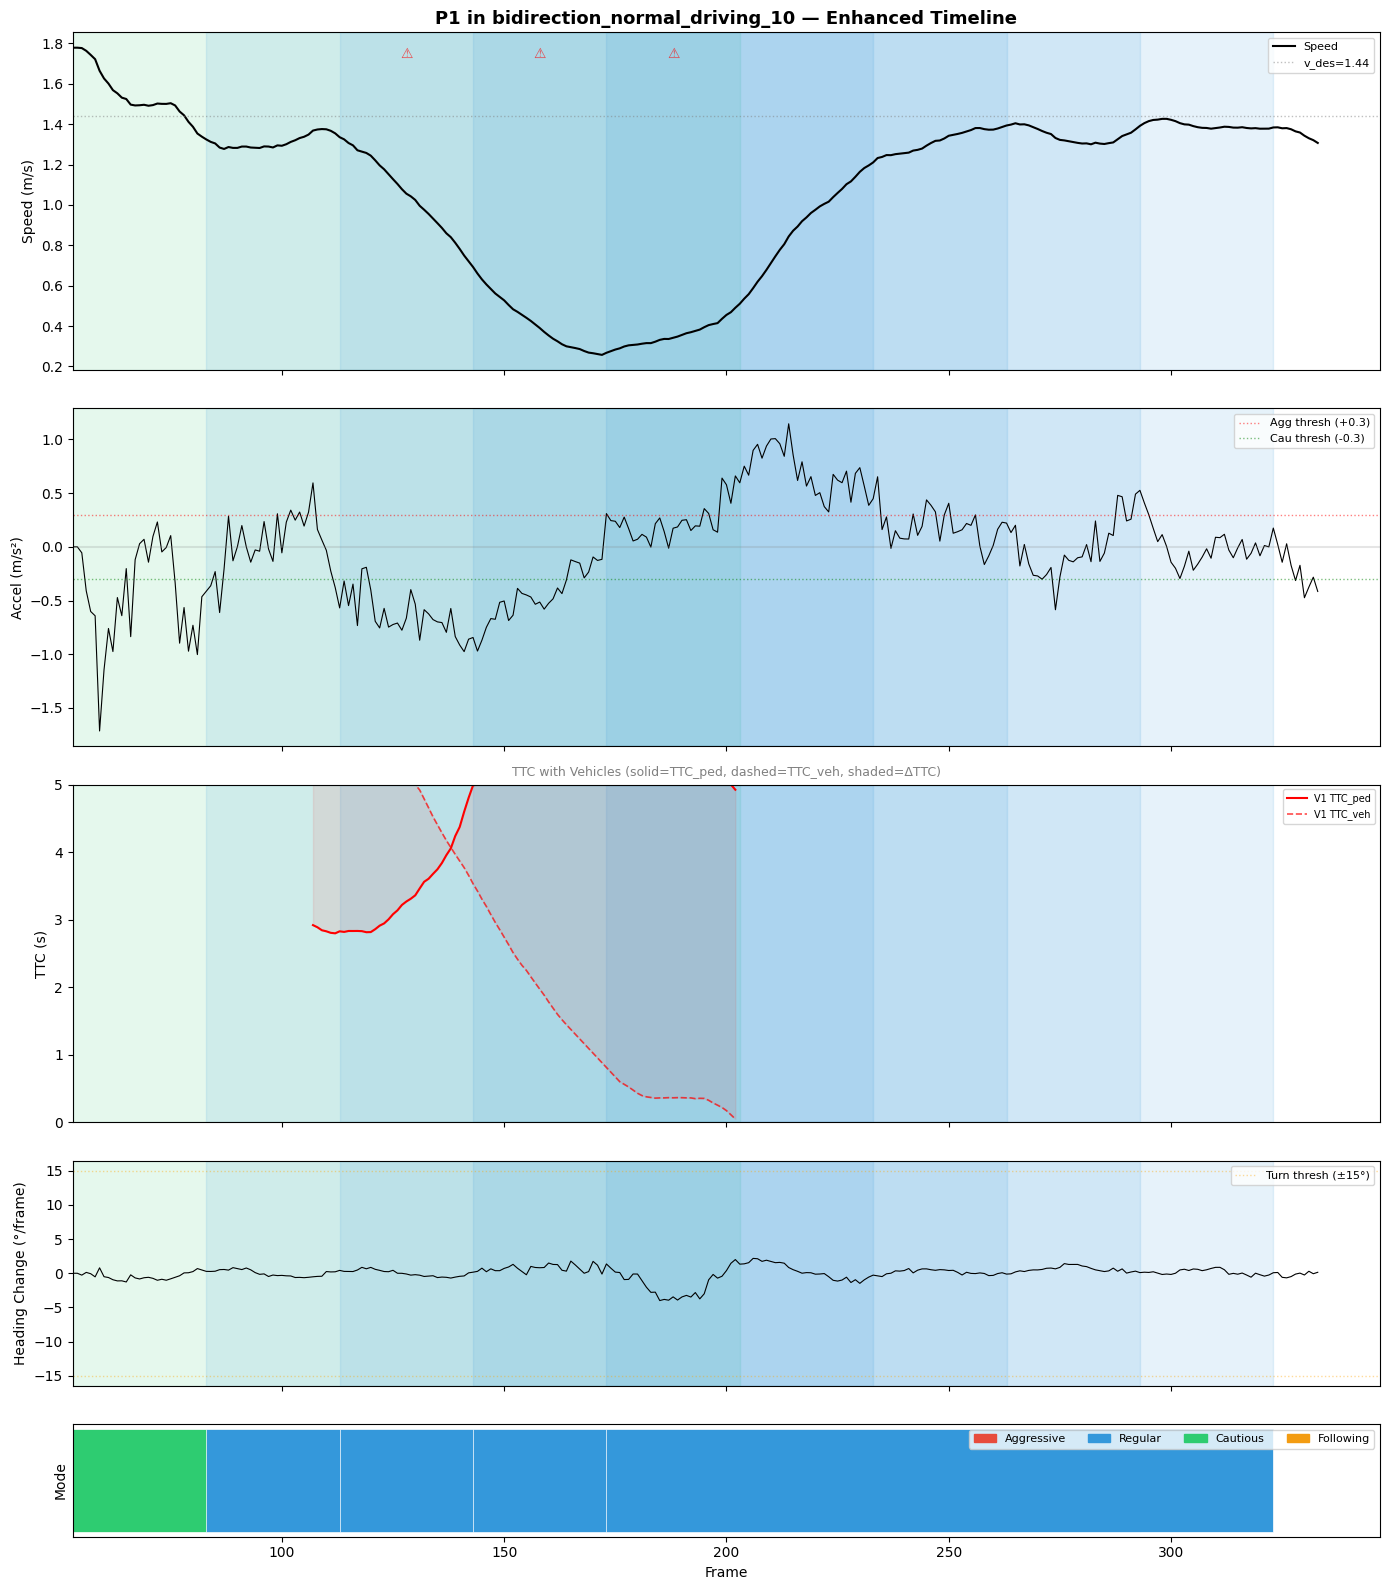


Window labels for P1:
  Start-  End | Mode         | Conf |  Speed |   Accel |  ΔTTC_i | Tp_min | Tv_min
  ----------------------------------------------------------------------------------
     53-  203 | Cautious     | Yes  |  0.940 |  -0.259 |  -11.98 |   2.83 |   0.36
     83-  233 | Regular      | Yes  |  0.808 |  -0.026 |  -10.94 |   2.83 |   0.36
    113-  263 | Regular      | Yes  |  0.808 |  +0.010 |   -5.69 |   2.83 |   0.36
    143-  293 | Regular      | No   |  0.864 |  +0.137 |   +1.46 |   4.99 |   0.36
    173-  323 | Regular      | No   |  1.059 |  +0.224 |    +nan |    inf |    inf

===== FOLLOWING example: P2 in back_interaction_04 =====


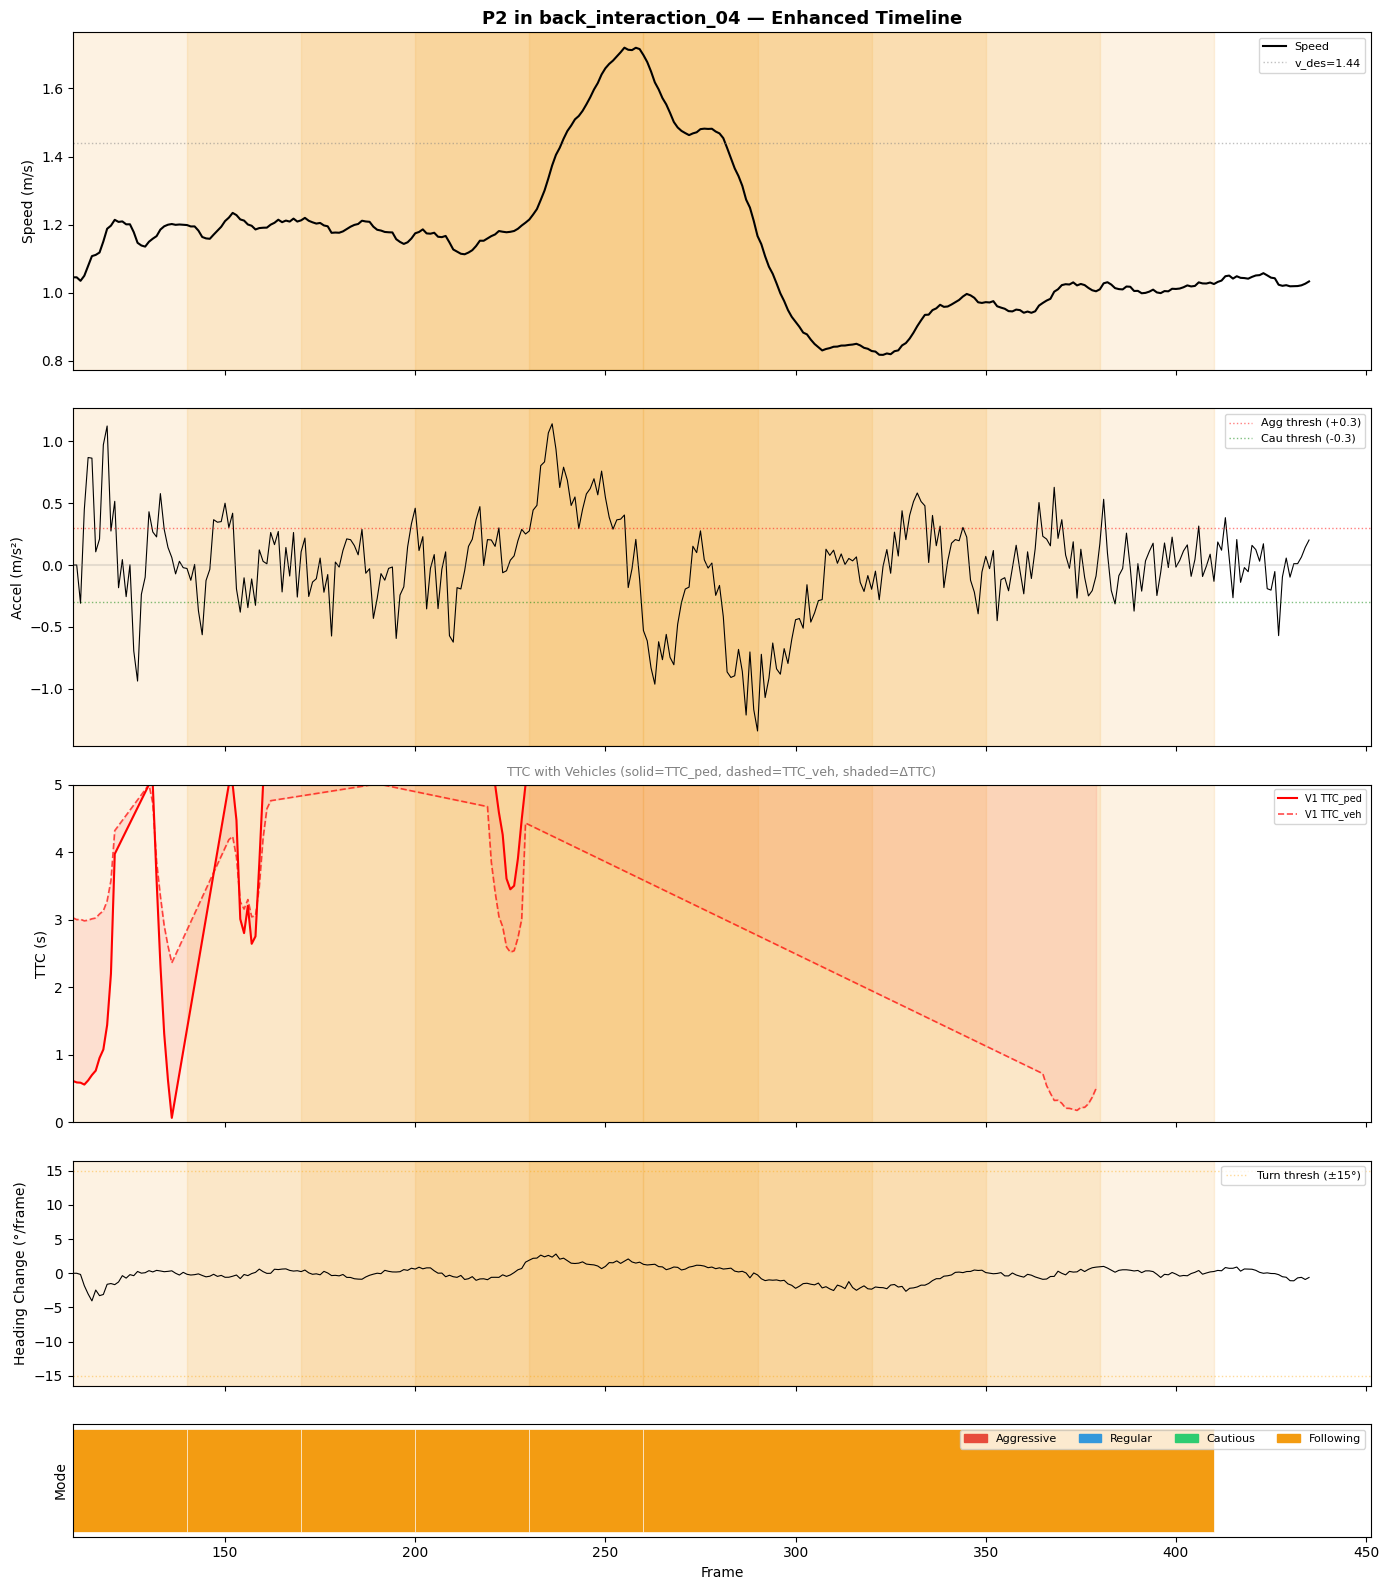


Window labels for P2:
  Start-  End | Mode         | Conf |  Speed |   Accel |  ΔTTC_i | Tp_min | Tv_min
  ----------------------------------------------------------------------------------
    110-  260 | Following    | No   |  1.246 |  +0.135 |    +nan |    inf |    inf
    140-  290 | Following    | No   |  1.309 |  +0.003 |    +nan |    inf |    inf
    170-  320 | Following    | No   |  1.253 |  -0.076 |    +nan |    inf |    inf
    200-  350 | Following    | No   |  1.197 |  -0.041 |    +nan |    inf |    inf
    230-  380 | Following    | No   |  1.161 |  -0.042 |    +nan |    inf |    inf
    260-  410 | Following    | No   |  1.059 |  -0.134 |    +nan |    inf |    inf


In [9]:
# Cell 8: Pick pedestrians to inspect
#
# Auto-select one from each mode for verification
import matplotlib.patches as mpatches

for mode_id, mode_name in enumerate(MODE_NAMES):
    subset = labels_df[labels_df['mode'] == mode_id]
    if subset.empty:
        print(f'No {mode_name} samples found.')
        continue
    sample = subset.iloc[0]
    sc = sample.get('scenario', '')
    pid = int(sample['ped_id'])
    print(f'\n===== {mode_name.upper()} example: P{pid} in {sc} =====')
    if sc:
        plot_ped_timeline(sc, pid)   # ← changed from plot_ped_timeline

In [13]:
# Cell 9: Consistency Checks

print('='*60)
print('LABELING CONSISTENCY CHECKS')
print('='*60)

agg = labels_df[labels_df['mode'] == 0]
cau = labels_df[labels_df['mode'] == 2]
fol = labels_df[labels_df['mode'] == 3]
reg = labels_df[labels_df['mode'] == 1]

print(f'\n1. Aggressive WITHOUT conflict: {(~agg["has_conflict"]).sum()}/{len(agg)}')
print(f'   (should be 0 or very few)')

print(f'\n2. Cautious WITHOUT conflict: {(~cau["has_conflict"]).sum()}/{len(cau)}')
print(f'   (should be 0)')

print(f'\n3. Following WITH conflict: {fol["has_conflict"].sum()}/{len(fol)}')
print(f'   (should be 0 — followers delegate TTC checks to leaders)')

print(f'\n4. Regular WITH conflict: {reg["has_conflict"].sum()}/{len(reg)}')
print(f'   (possible: neutral response in conflict = neither accel nor decel)')

print(f'\n5. Mean speed by mode:')
for i, name in enumerate(MODE_NAMES):
    s = labels_df[labels_df['mode']==i]['mean_speed']
    if len(s) > 0:
        print(f'   {name:12s}: {s.mean():.3f} +/- {s.std():.3f} m/s')

print(f'\n6. Mean accel by mode:')
for i, name in enumerate(MODE_NAMES):
    a = labels_df[labels_df['mode']==i]['mean_accel']
    if len(a) > 0:
        print(f'   {name:12s}: {a.mean():+.4f} +/- {a.std():.4f} m/s^2')

LABELING CONSISTENCY CHECKS

1. Aggressive WITHOUT conflict: 0/24
   (should be 0 or very few)

2. Cautious WITHOUT conflict: 0/10
   (should be 0)

3. Following WITH conflict: 0/442
   (should be 0 — followers delegate TTC checks to leaders)

4. Regular WITH conflict: 177/540
   (possible: neutral response in conflict = neither accel nor decel)

5. Mean speed by mode:
   aggressive  : 1.123 +/- 0.195 m/s
   regular     : 1.144 +/- 0.239 m/s
   cautious    : 0.934 +/- 0.144 m/s
   following   : 1.109 +/- 0.190 m/s

6. Mean accel by mode:
   aggressive  : +0.1496 +/- 0.0548 m/s^2
   regular     : +0.0045 +/- 0.0762 m/s^2
   cautious    : -0.1895 +/- 0.0596 m/s^2
   following   : +0.0121 +/- 0.0747 m/s^2


In [14]:
# Cell: Generate Trajectory Animation Videos
#
# Produces MP4 videos for each scenario with mode-colored pedestrian trajectories.
# Requires: pip install matplotlib (ffmpeg for MP4, or falls back to GIF via pillow)

import matplotlib.animation as animation

VIDEO_OUTPUT_DIR = r"/Volumes/Seagate129/P2V_Interaction_Modeling/Video/P2V_controlled"
FPS_DATA = 30
FPS_VIDEO = 15
TRAIL_LENGTH = 60  # 2 seconds of trail

def generate_scenario_video(scenario_name, output_dir=VIDEO_OUTPUT_DIR):
    """Generate animated MP4 for one scenario."""
    ped_data, veh_data, ped_file, veh_file = load_scenario_data(scenario_name)
    if ped_data.empty:
        print(f'  [SKIP] {scenario_name}: no ped data')
        return

    os.makedirs(output_dir, exist_ok=True)

    frame_min = int(ped_data['frame'].min())
    frame_max = int(ped_data['frame'].max())
    if not veh_data.empty:
        frame_min = min(frame_min, int(veh_data['frame'].min()))
        frame_max = max(frame_max, int(veh_data['frame'].max()))

    # Build lookup dicts
    ped_lookup = {}
    for _, row in ped_data.iterrows():
        ped_lookup[(int(row['id']), int(row['frame']))] = (row['x'], row['y'])

    ped_ids = sorted(ped_data['id'].unique())
    ped_frame_ranges = {}
    for pid in ped_ids:
        grp = ped_data[ped_data['id'] == pid]
        ped_frame_ranges[int(pid)] = (int(grp['frame'].min()), int(grp['frame'].max()))

    veh_lookup = {}
    veh_ids = []
    if not veh_data.empty:
        if 'veh_vx' not in veh_data.columns and 'psi' in veh_data.columns:
            veh_data['veh_vx'] = veh_data['vel'] * np.cos(veh_data['psi'])
            veh_data['veh_vy'] = veh_data['vel'] * np.sin(veh_data['psi'])
        veh_ids = sorted(veh_data['id'].unique())
        for _, row in veh_data.iterrows():
            veh_lookup[(int(row['id']), int(row['frame']))] = (row['x'], row['y'])

    # Conflict frames lookup
    conflict_frames = set()
    sc_labels = labels_df[labels_df['scenario'] == scenario_name] if 'scenario' in labels_df.columns else labels_df
    for _, row in sc_labels[sc_labels['has_conflict'] == True].iterrows():
        pid = int(row['ped_id'])
        for f in range(int(row['frame_start']), int(row['frame_end'])):
            conflict_frames.add((pid, f))

    # Mode at frame helper
    def get_mode_at_frame(pid, frame):
        pid_labels = sc_labels[sc_labels['ped_id'] == pid]
        for _, row in pid_labels.iterrows():
            if row['frame_start'] <= frame < row['frame_end']:
                return int(row['mode'])
        return 1

    # Axis limits
    all_x = ped_data['x'].tolist() + (veh_data['x'].tolist() if not veh_data.empty else [])
    all_y = ped_data['y'].tolist() + (veh_data['y'].tolist() if not veh_data.empty else [])
    xm = (max(all_x) - min(all_x)) * 0.1 + 0.5
    ym = (max(all_y) - min(all_y)) * 0.1 + 0.5
    xlim = (min(all_x) - xm, max(all_x) + xm)
    ylim = (min(all_y) - ym, max(all_y) + ym)

    frame_step = max(1, FPS_DATA // FPS_VIDEO)
    render_frames = list(range(frame_min, frame_max + 1, frame_step))

    # Setup figure
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    for pid in ped_ids:
        grp = ped_data[ped_data['id'] == pid].sort_values('frame')
        ax.plot(grp['x'], grp['y'], '--', color='gray', alpha=0.2, linewidth=0.8)
    if not veh_data.empty:
        for vid in veh_ids:
            grp = veh_data[veh_data['id'] == vid].sort_values('frame')
            ax.plot(grp['x'], grp['y'], '-', color='navy', alpha=0.15, linewidth=1.5)

    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_xlabel('X Position (m)'); ax.set_ylabel('Y Position (m)')
    ax.set_aspect('equal'); ax.grid(True, alpha=0.2)

    handles = [Line2D([0],[0], color='gray', linestyle='--', alpha=0.4, label='Ped GT')]
    if veh_ids:
        handles.append(Line2D([0],[0], color='navy', linewidth=2, label='Vehicle'))
    for i in range(4):
        handles.append(mpatches.Patch(color=MODE_COLORS[i], label=MODE_LABELS[i]))
    ax.legend(handles=handles, loc='upper right', fontsize=8, framealpha=0.9)

    title_text = ax.set_title(f'{scenario_name} — Frame {frame_min}', fontsize=13, fontweight='bold')
    dynamic_artists = []

    def animate(idx):
        nonlocal dynamic_artists
        for a in dynamic_artists:
            a.remove()
        dynamic_artists.clear()

        cf = render_frames[idx]
        title_text.set_text(f'{scenario_name} — Frame {cf} ({(cf - frame_min)/FPS_DATA:.1f}s)')

        # Vehicles
        for vid in veh_ids:
            if (vid, cf) in veh_lookup:
                vx, vy = veh_lookup[(vid, cf)]
                dynamic_artists.extend(ax.plot(vx, vy, 's', color='navy', markersize=10,
                                               markeredgecolor='white', markeredgewidth=1, zorder=10))
                tx, ty = [], []
                for tf in range(max(frame_min, cf - TRAIL_LENGTH), cf + 1):
                    if (vid, tf) in veh_lookup:
                        px, py = veh_lookup[(vid, tf)]
                        tx.append(px); ty.append(py)
                if len(tx) > 1:
                    dynamic_artists.extend(ax.plot(tx, ty, '-', color='navy', alpha=0.5, linewidth=2, zorder=5))

        # Pedestrians
        for pid in ped_ids:
            pid = int(pid)
            fstart, fend = ped_frame_ranges[pid]
            if cf < fstart or cf > fend or (pid, cf) not in ped_lookup:
                continue

            px, py = ped_lookup[(pid, cf)]
            mode = get_mode_at_frame(pid, cf)
            color = MODE_COLORS[mode]

            # Mode-colored trail
            trail_frames = range(max(fstart, cf - TRAIL_LENGTH), cf + 1)
            seg_x, seg_y, seg_mode = [], [], None
            for tf in trail_frames:
                if (pid, tf) not in ped_lookup:
                    continue
                tx, ty = ped_lookup[(pid, tf)]
                tf_mode = get_mode_at_frame(pid, tf)
                if seg_mode is None:
                    seg_mode = tf_mode; seg_x.append(tx); seg_y.append(ty)
                elif tf_mode == seg_mode:
                    seg_x.append(tx); seg_y.append(ty)
                else:
                    if len(seg_x) > 1:
                        dynamic_artists.extend(ax.plot(seg_x, seg_y, '-', color=MODE_COLORS[seg_mode],
                                                       alpha=0.6, linewidth=2, zorder=6))
                    seg_x = [seg_x[-1], tx]; seg_y = [seg_y[-1], ty]; seg_mode = tf_mode
            if len(seg_x) > 1:
                dynamic_artists.extend(ax.plot(seg_x, seg_y, '-', color=MODE_COLORS[seg_mode],
                                               alpha=0.6, linewidth=2, zorder=6))

            # Current position
            dynamic_artists.extend(ax.plot(px, py, 'o', color=color, markersize=9,
                                           markeredgecolor='white', markeredgewidth=1.2, zorder=15))
            dynamic_artists.append(ax.annotate(f'P{pid}', (px, py), textcoords='offset points',
                                               xytext=(6, 6), fontsize=7, fontweight='bold',
                                               color=color, zorder=16))
            if (pid, cf) in conflict_frames:
                dynamic_artists.append(ax.annotate('\u26A0', (px, py), textcoords='offset points',
                                                   xytext=(-8, 8), fontsize=11, color='red',
                                                   fontweight='bold', zorder=17))
        return dynamic_artists

    print(f'  Rendering {scenario_name}: {len(render_frames)} frames ({len(render_frames)/FPS_VIDEO:.1f}s) ...')
    anim = animation.FuncAnimation(fig, animate, frames=len(render_frames),
                                    interval=1000//FPS_VIDEO, blit=False, repeat=False)

    output_path = os.path.join(output_dir, f'{scenario_name}_modes.mp4')
    try:
        writer = animation.FFMpegWriter(fps=FPS_VIDEO, bitrate=2000)
        anim.save(output_path, writer=writer, dpi=150)
    except Exception as e:
        print(f'    ffmpeg failed ({e}), trying GIF...')
        output_path = output_path.replace('.mp4', '.gif')
        try:
            anim.save(output_path, writer=animation.PillowWriter(fps=FPS_VIDEO), dpi=80)
        except Exception as e2:
            print(f'    Also failed: {e2}. Install ffmpeg: conda install ffmpeg')
            plt.close(fig); return
    
    plt.close(fig)
    sz = os.path.getsize(output_path) / (1024*1024)
    print(f'  ✓ Saved: {output_path} ({sz:.1f} MB)')

# Generate for all scenarios
scenarios = labels_df['scenario'].unique() if 'scenario' in labels_df.columns else []
print(f'Generating videos for {len(scenarios)} scenarios → {VIDEO_OUTPUT_DIR}/')
for sc in scenarios:
    generate_scenario_video(sc)
print('Done!')

Generating videos for 26 scenarios → /Volumes/Seagate129/P2V_Interaction_Modeling/Video/P2V_controlled/
  Rendering back_interaction_04: 163 frames (10.9s) ...
    ffmpeg failed ([Errno 2] No such file or directory: 'ffmpeg'), trying GIF...
  ✓ Saved: /Volumes/Seagate129/P2V_Interaction_Modeling/Video/P2V_controlled/back_interaction_04_modes.gif (0.9 MB)
  Rendering back_interaction_01: 211 frames (14.1s) ...
    ffmpeg failed ([Errno 2] No such file or directory: 'ffmpeg'), trying GIF...
  ✓ Saved: /Volumes/Seagate129/P2V_Interaction_Modeling/Video/P2V_controlled/back_interaction_01_modes.gif (1.0 MB)
  Rendering back_interaction_02: 174 frames (11.6s) ...
    ffmpeg failed ([Errno 2] No such file or directory: 'ffmpeg'), trying GIF...
  ✓ Saved: /Volumes/Seagate129/P2V_Interaction_Modeling/Video/P2V_controlled/back_interaction_02_modes.gif (0.9 MB)
  Rendering back_interaction_03: 158 frames (10.5s) ...
    ffmpeg failed ([Errno 2] No such file or directory: 'ffmpeg'), trying GIF...


In [18]:
# Cell 11: Save Verified Labels
#
# After visual verification, save the final labels for GNN training.

output_path = r'/Volumes/Seagate129/P2V_Interaction_Modeling/Data/campus_field/pseudo_labels.csv'
labels_df.to_csv(output_path, index=False)
print(f'Labels saved to: {output_path}')
print(f'Total: {len(labels_df)} samples across {labels_df["scenario"].nunique() if "scenario" in labels_df.columns else "?"} scenarios')
print(f'\nReady for GNN training!')

Labels saved to: /Volumes/Seagate129/P2V_Interaction_Modeling/Data/campus_field/pseudo_labels.csv
Total: 1016 samples across 26 scenarios

Ready for GNN training!


# DUT Campus field data labeling

In [1]:
# Cell 1: Setup
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# >>> EDIT THESE PATHS <<<
# ============================================================
PROJECT_DIR = '.'   # folder containing mode_config.py, pseudo_labeler.py

# Choose your dataset:
# data_dir = r"/Volumes/Seagate129/P2V_Interaction_Modeling/Data/p2p_controlled"       # ped_only = True
data_dir = r"/Volumes/Seagate129/P2V_Interaction_Modeling/Data/campus_field"       # ped_only = False
# data_dir = r"/Volumes/Seagate129/P2V_Interaction_Modeling/Data/campus_field"            # ped_only = False

ped_only = False
# ============================================================

sys.path.insert(0, PROJECT_DIR)
from pseudo_labeler import PseudoLabeler, FeatureExtractor, label_all_scenarios
from mode_config import NUM_MODES, MODE_NAMES

MODE_COLORS = {0: '#E74C3C', 1: '#3498DB', 2: '#2ECC71', 3: '#F39C12'}
MODE_LABELS = {0: 'Aggressive', 1: 'Regular', 2: 'Cautious', 3: 'Following'}

# Discover scenario files (same pattern as your GA notebook)
all_files = [f for f in os.listdir(data_dir) if f.endswith('.csv')]
print(f'Data directory: {data_dir}')
print(f'CSV files found: {len(all_files)}')

scenario_files = []
if ped_only:
    for f in all_files:
        scenario_files.append((f, None))
else:
    scenario_dict = {}
    for f in all_files:
        key = f.split('_traj_')[0]
        scenario_dict.setdefault(key, {})
        if '_ped_' in f:
            scenario_dict[key]['ped'] = f
        elif '_veh_' in f:
            scenario_dict[key]['veh'] = f
    for key, files in scenario_dict.items():
        ped = files.get('ped')
        veh = files.get('veh')
        if ped:
            scenario_files.append((ped, veh))

print(f'Scenarios discovered: {len(scenario_files)}')
for pf, vf in scenario_files[:5]:
    print(f'  ped: {pf}  |  veh: {vf}')

Data directory: /Volumes/Seagate129/P2V_Interaction_Modeling/Data/campus_field
CSV files found: 56
Scenarios discovered: 28
  ped: intersection_01_traj_ped_filtered.csv  |  veh: intersection_01_traj_veh_filtered.csv
  ped: intersection_02_traj_ped_filtered.csv  |  veh: intersection_02_traj_veh_filtered.csv
  ped: intersection_03_traj_ped_filtered.csv  |  veh: intersection_03_traj_veh_filtered.csv
  ped: intersection_04_traj_ped_filtered.csv  |  veh: intersection_04_traj_veh_filtered.csv
  ped: intersection_05_traj_ped_filtered.csv  |  veh: intersection_05_traj_veh_filtered.csv


In [2]:
# Cell 2: Run Pseudo-Labeling
labels_df = label_all_scenarios(data_dir, ped_only=ped_only)

print(f'Total labeled samples: {len(labels_df)}')
print(f'\nMode distribution:')
print(labels_df['mode_name'].value_counts().to_string())
print(f'\nConflict rate: {labels_df["has_conflict"].mean()*100:.1f}%')
print(f'Follower rate: {labels_df["is_follower"].mean()*100:.1f}%')
labels_df.head(10)

Total labeled samples: 10982

Mode distribution:
mode_name
following     5985
regular       4933
cautious        38
aggressive      26

Conflict rate: 5.3%
Follower rate: 54.5%


,ped_id,frame_start,frame_end,mode,mode_name,has_conflict,is_follower,mean_speed,mean_accel,delta_ttc_init,delta_ttc_final,ttc_ped_min,ttc_veh_min,conflict_veh_id,conflict_angle,scenario
0,0,1,151,1,regular,False,False,0.980590,-0.124224,2.514126,3.465639,3.535942,0.266084,0.0,89.196847,intersection_01
1,1,1,151,1,regular,False,False,0.534693,-0.089107,NaN,NaN,inf,inf,NaN,NaN,intersection_01
2,2,1,151,1,regular,False,False,1.356667,0.114281,NaN,NaN,inf,inf,NaN,NaN,intersection_01
3,3,1,151,1,regular,False,False,1.394421,0.031264,NaN,NaN,inf,inf,NaN,NaN,intersection_01
4,4,1,151,1,regular,False,False,1.295339,0.028713,NaN,NaN,inf,inf,NaN,NaN,intersection_01
5,5,1,151,1,regular,False,False,0.814868,0.093948,NaN,NaN,inf,inf,NaN,NaN,intersection_01
6,6,1,151,1,regular,False,False,1.671461,-0.075295,NaN,NaN,inf,inf,NaN,NaN,intersection_01
7,7,1,151,1,regular,False,False,1.142203,0.091735,NaN,NaN,inf,inf,NaN,NaN,intersection_01
8,8,1,151,1,regular,False,False,1.161374,0.076303,NaN,NaN,inf,inf,NaN,NaN,intersection_01
9,10,1,151,1,regular,False,False,1.394441,-0.026316,NaN,NaN,inf,inf,NaN,NaN,intersection_01


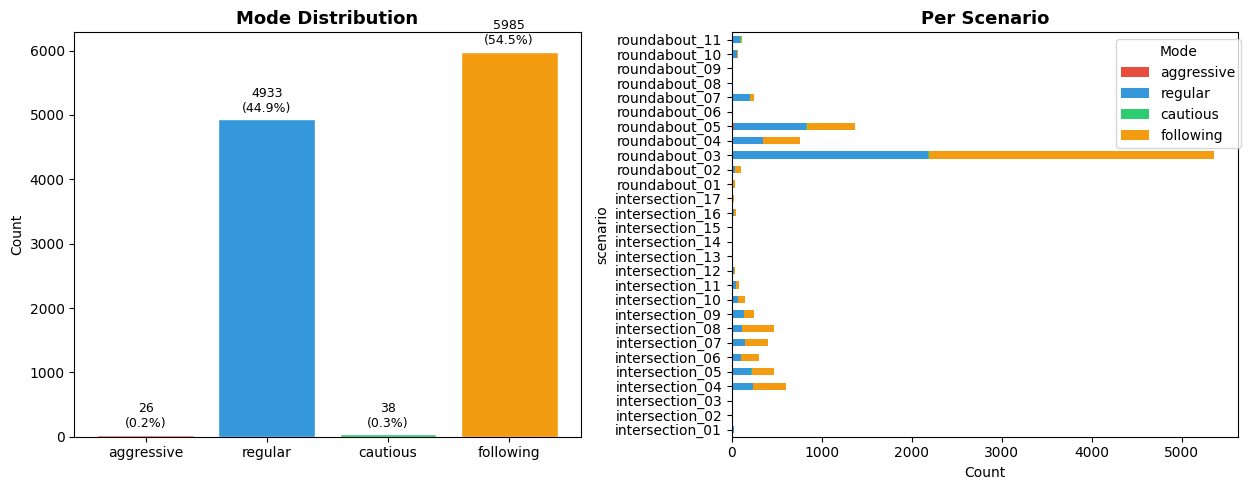

In [3]:
# Cell 3: Mode Distribution Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
dist = labels_df['mode_name'].value_counts().reindex(MODE_NAMES, fill_value=0)
colors = [MODE_COLORS[i] for i in range(NUM_MODES)]
axes[0].bar(dist.index, dist.values, color=colors, edgecolor='white')
axes[0].set_title('Mode Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, (name, count) in enumerate(zip(dist.index, dist.values)):
    axes[0].text(i, count + max(dist.values)*0.02,
                f'{count}\n({100*count/max(len(labels_df),1):.1f}%)',
                ha='center', fontsize=9)

# Per-scenario breakdown
if 'scenario' in labels_df.columns:
    sc = labels_df.groupby(['scenario', 'mode_name']).size().unstack(fill_value=0)
    sc = sc.reindex(columns=MODE_NAMES, fill_value=0)
    sc.plot(kind='barh', stacked=True, ax=axes[1],
            color=[MODE_COLORS[i] for i in range(NUM_MODES)])
    axes[1].set_title('Per Scenario', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Count')
    axes[1].legend(title='Mode', bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

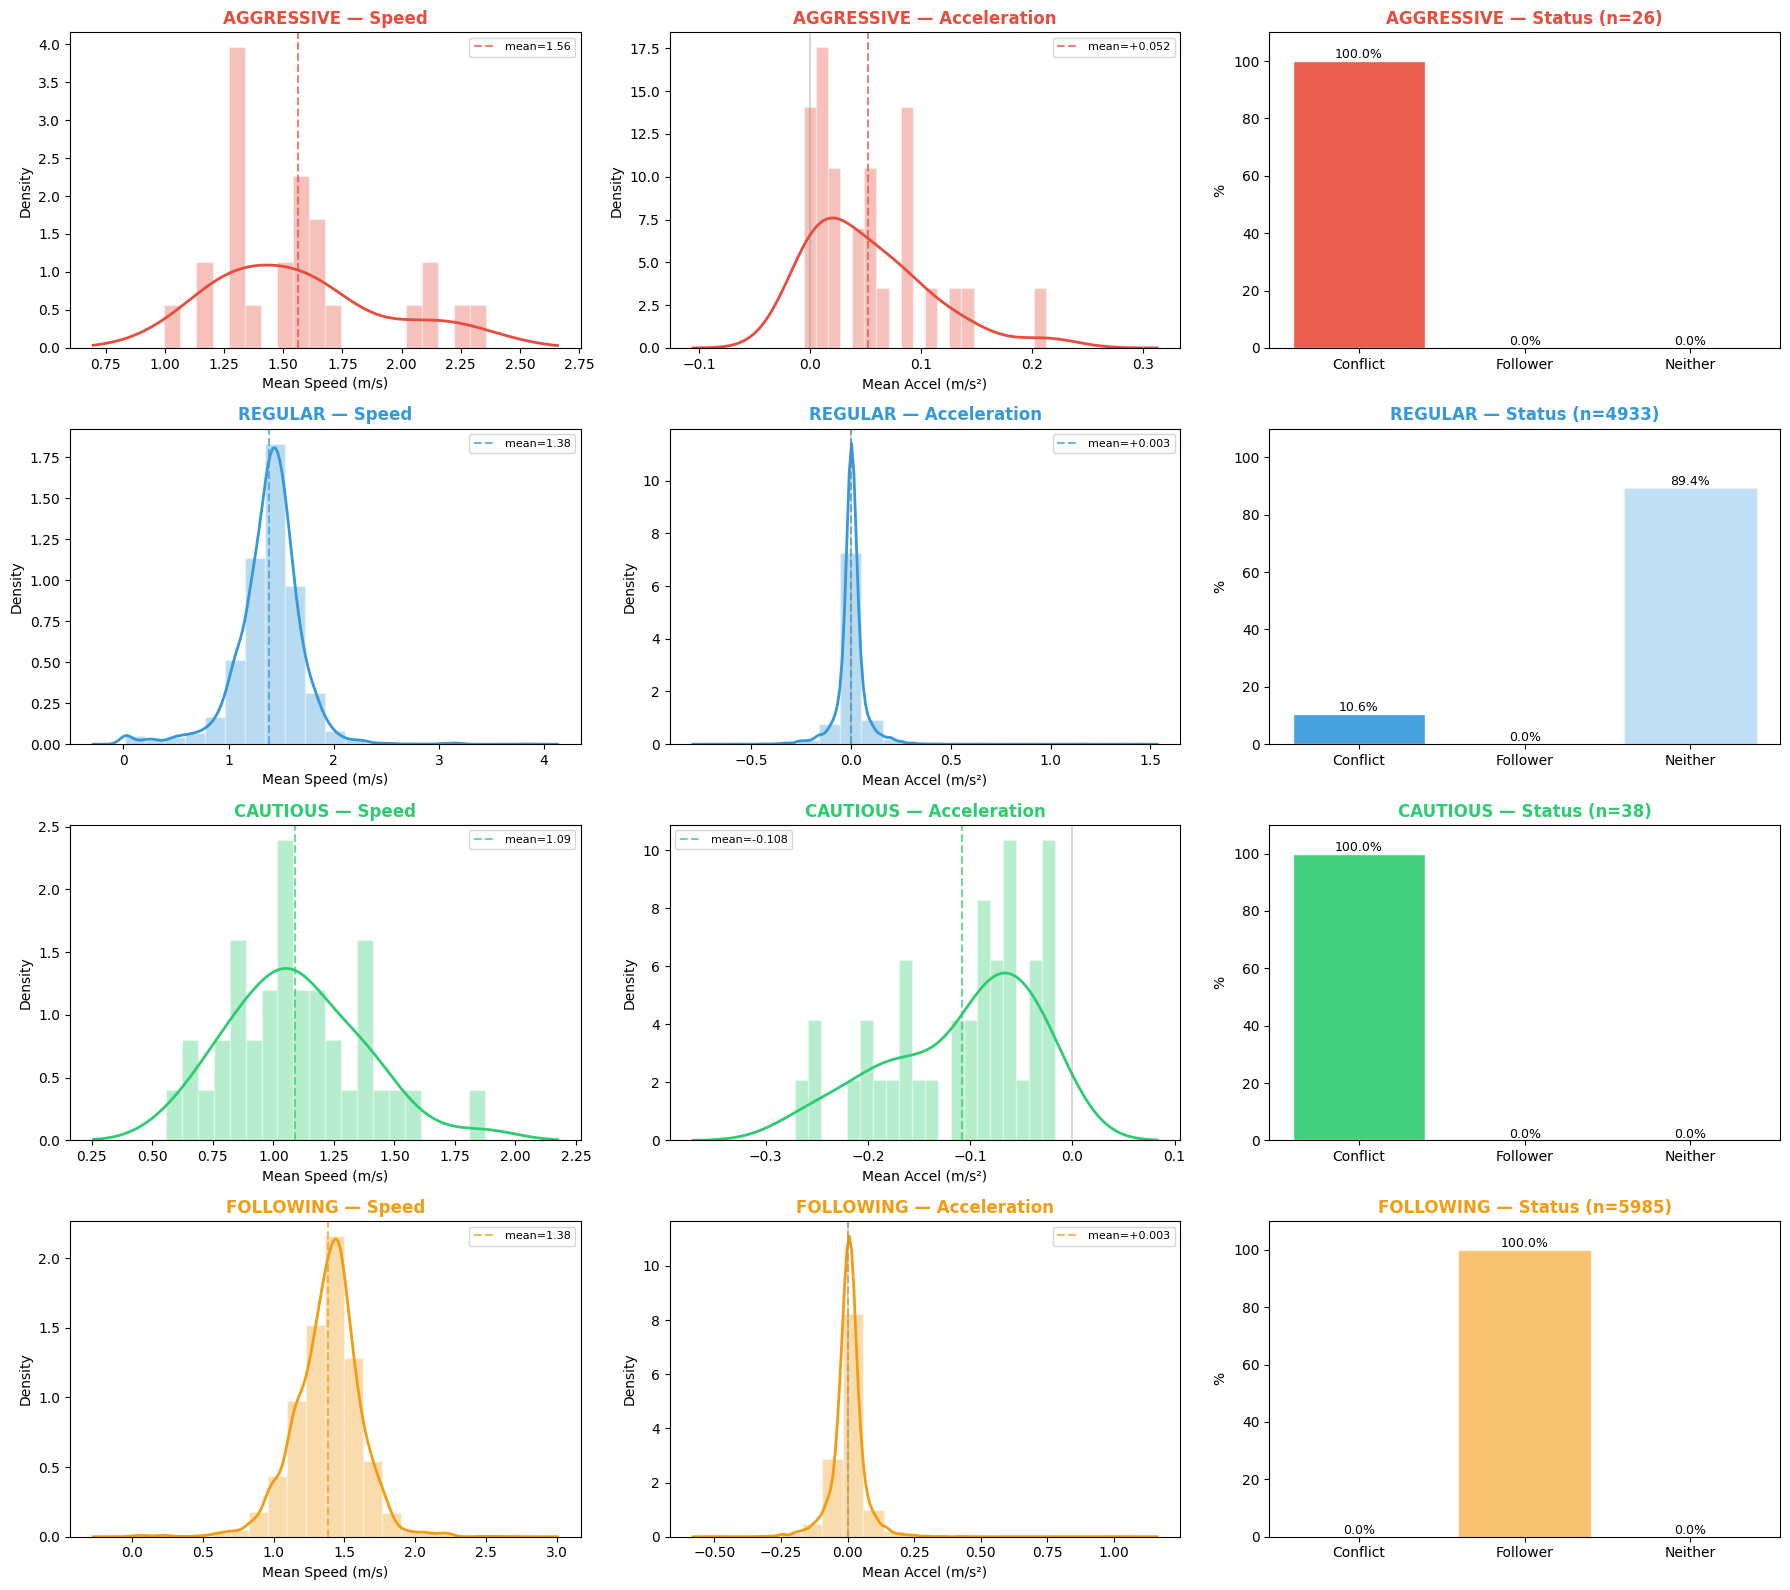

In [4]:
#Feature Statistics — Speed & Acceleration by Mode (Separated + KDE)
from scipy.stats import gaussian_kde
 
fig, axes = plt.subplots(NUM_MODES, 3, figsize=(18, 4 * NUM_MODES))
 
for mode_id, mode_name in enumerate(MODE_NAMES):
    subset = labels_df[labels_df['mode'] == mode_id]
    color = MODE_COLORS[mode_id]
    row = axes[mode_id]
 
    # --- Speed ---
    ax_spd = row[0]
    if not subset.empty and subset['mean_speed'].std() > 1e-6:
        speeds = subset['mean_speed'].dropna().values
        ax_spd.hist(speeds, bins=20, alpha=0.35, color=color, density=True, edgecolor='white')
        # KDE (Gaussian regression line)
        xs = np.linspace(speeds.min() - 0.3, speeds.max() + 0.3, 200)
        kde = gaussian_kde(speeds)
        ax_spd.plot(xs, kde(xs), color=color, linewidth=2)
        ax_spd.axvline(x=np.mean(speeds), color=color, linestyle='--', alpha=0.7,
                       label=f'mean={np.mean(speeds):.2f}')
    ax_spd.set_title(f'{mode_name.upper()} — Speed', fontweight='bold', color=color)
    ax_spd.set_xlabel('Mean Speed (m/s)')
    ax_spd.set_ylabel('Density')
    ax_spd.legend(fontsize=8)
 
    # --- Acceleration ---
    ax_acc = row[1]
    if not subset.empty and subset['mean_accel'].std() > 1e-6:
        accels = subset['mean_accel'].dropna().values
        ax_acc.hist(accels, bins=20, alpha=0.35, color=color, density=True, edgecolor='white')
        xs = np.linspace(accels.min() - 0.1, accels.max() + 0.1, 200)
        kde = gaussian_kde(accels)
        ax_acc.plot(xs, kde(xs), color=color, linewidth=2)
        ax_acc.axvline(x=np.mean(accels), color=color, linestyle='--', alpha=0.7,
                       label=f'mean={np.mean(accels):+.3f}')
        ax_acc.axvline(x=0, color='gray', linestyle='-', alpha=0.3)
    ax_acc.set_title(f'{mode_name.upper()} — Acceleration', fontweight='bold', color=color)
    ax_acc.set_xlabel('Mean Accel (m/s²)')
    ax_acc.set_ylabel('Density')
    ax_acc.legend(fontsize=8)
 
    # --- Conflict & Follower rates ---
    # --- Conflict & Follower rates ---
    ax_bar = row[2]
    n_total = len(subset)
    if n_total > 0:
        conflict_pct = subset['has_conflict'].mean() * 100
        follower_pct = subset['is_follower'].mean() * 100
        normal_pct = 100 - conflict_pct - follower_pct
    else:
        conflict_pct = follower_pct = normal_pct = 0

    bar_vals = [conflict_pct, follower_pct, max(normal_pct, 0)]
    bar_alphas = [0.9, 0.6, 0.3]
    for j, (label, val, a) in enumerate(zip(['Conflict', 'Follower', 'Neither'], bar_vals, bar_alphas)):
        ax_bar.bar(label, val, color=color, alpha=a, edgecolor='white')
        ax_bar.text(j, val + 1, f'{val:.1f}%', ha='center', fontsize=9)
    ax_bar.set_title(f'{mode_name.upper()} — Status (n={n_total})', fontweight='bold', color=color)
    ax_bar.set_ylabel('%')
    ax_bar.set_ylim(0, 110)
 
plt.tight_layout()
plt.show()

In [5]:
# Cell: Diagnostic — Why no Cautious labels?
#
# Paste this into your notebook AFTER Cell 2 (labels_df exists).
# It checks every conflict window and reports which of the 4 Cautious conditions fails.

print('=' * 70)
print('CAUTIOUS DIAGNOSTIC: checking all conflict windows')
print('=' * 70)

conflict_windows = labels_df[labels_df['has_conflict'] == True]
print(f'\nTotal windows with has_conflict=True: {len(conflict_windows)}')

if len(conflict_windows) == 0:
    print('\n*** NO CONFLICT WINDOWS AT ALL ***')
    print('Problem is at Level 1: track_ttc_evolution() never finds conflict.')
    print('Check:')
    print('  - Are vehicle CSV files being loaded? (veh_data not empty)')
    print('  - Does compute_ttc() ever return conflict=True?')
    print('  - Is conflict_frame_count >= 2? (the minimum threshold)')
else:
    # Check each condition for conflict windows
    has_diag = 'delta_ttc_init' in labels_df.columns
    
    if not has_diag:
        print('\n*** Diagnostic columns missing (delta_ttc_init, ttc_ped_min, ttc_veh_min) ***')
        print('Are you using the NEW pseudo_labeler.py? The old one does not output these.')
        print('Make sure to restart kernel and reimport after replacing the file.')
    else:
        print(f'\n--- Condition breakdown for {len(conflict_windows)} conflict windows ---\n')
        
        # Condition 2: ΔTTC_init < 0 (ped advantaged)
        valid_delta = conflict_windows['delta_ttc_init'].notna()
        cond2 = conflict_windows.loc[valid_delta, 'delta_ttc_init'] < 0
        n_cond2 = cond2.sum()
        print(f'Cond 2: ΔTTC_init < 0 (ped advantaged):  {n_cond2}/{len(conflict_windows)}')
        if n_cond2 > 0:
            vals = conflict_windows.loc[valid_delta & cond2, 'delta_ttc_init']
            print(f'         range: [{vals.min():.3f}, {vals.max():.3f}]')
        
        # Show ΔTTC_init distribution
        delta_vals = conflict_windows.loc[valid_delta, 'delta_ttc_init']
        print(f'\n  ΔTTC_init distribution (all conflict windows):')
        print(f'    min={delta_vals.min():.3f}, median={delta_vals.median():.3f}, '
              f'max={delta_vals.max():.3f}, mean={delta_vals.mean():.3f}')
        
        # Condition 3: mean_accel < -0.3
        cond3 = conflict_windows['mean_accel'] < -0.01
        n_cond3 = cond3.sum()
        print(f'\nCond 3: mean_accel < -0.1 (sig decel):  {n_cond3}/{len(conflict_windows)}')
        if n_cond3 > 0:
            vals = conflict_windows.loc[cond3, 'mean_accel']
            print(f'         range: [{vals.min():.3f}, {vals.max():.3f}]')
        
        print(f'\n  mean_accel distribution (all conflict windows):')
        print(f'    min={conflict_windows["mean_accel"].min():.3f}, '
              f'median={conflict_windows["mean_accel"].median():.3f}, '
              f'mean={conflict_windows["mean_accel"].mean():.3f}, '
              f'max={conflict_windows["mean_accel"].max():.3f}')
        
        # Condition 4a: ttc_veh_min < 0.5 (vehicle converges to 0)
        cond4a = conflict_windows['ttc_veh_min'] < 0.8
        n_cond4a = cond4a.sum()
        print(f'\nCond 4a: ttc_veh_min < 0.5 (veh→0):    {n_cond4a}/{len(conflict_windows)}')
        if n_cond4a > 0:
            vals = conflict_windows.loc[cond4a, 'ttc_veh_min']
            print(f'          range: [{vals.min():.3f}, {vals.max():.3f}]')
        
        print(f'\n  ttc_veh_min distribution (all conflict windows):')
        tv = conflict_windows['ttc_veh_min']
        tv_finite = tv[tv < 1e6]
        if len(tv_finite) > 0:
            print(f'    min={tv_finite.min():.3f}, median={tv_finite.median():.3f}, '
                  f'max={tv_finite.max():.3f}')
        else:
            print(f'    ALL inf (no valid TTC_veh convergence data)')
        
        # Condition 4b: ttc_ped_min > 0.5 (ped stays away)
        cond4b = conflict_windows['ttc_ped_min'] > 0.5
        n_cond4b = cond4b.sum()
        print(f'\nCond 4b: ttc_ped_min > 0.5 (ped stays): {n_cond4b}/{len(conflict_windows)}')
        
        print(f'\n  ttc_ped_min distribution (all conflict windows):')
        tp = conflict_windows['ttc_ped_min']
        tp_finite = tp[tp < 1e6]
        if len(tp_finite) > 0:
            print(f'    min={tp_finite.min():.3f}, median={tp_finite.median():.3f}, '
                  f'max={tp_finite.max():.3f}')
        
        # Combined: how many pass ALL 4 conditions?
        all_cond = valid_delta & cond2 & cond3 & cond4a & cond4b
        n_all = all_cond.sum()
        print(f'\n--- ALL 4 conditions met (would be Cautious): {n_all}/{len(conflict_windows)} ---')
        
        # Partial passes
        c2_and_c3 = (valid_delta & cond2 & cond3).sum()
        c2_and_c4 = (valid_delta & cond2 & cond4a & cond4b).sum()
        c3_and_c4 = (cond3 & cond4a & cond4b).sum()
        print(f'\n  Partial combinations:')
        print(f'    Cond2 + Cond3 (advantaged + decel):     {c2_and_c3}')
        print(f'    Cond2 + Cond4 (advantaged + veh wins):  {c2_and_c4}')
        print(f'    Cond3 + Cond4 (decel + veh wins):       {c3_and_c4}')
        
        # Show nearest misses
        if n_all == 0 and c2_and_c3 > 0:
            print(f'\n*** LIKELY BOTTLENECK: Condition 4 (convergence) ***')
            subset = conflict_windows[valid_delta & cond2 & cond3]
            print(f'    Windows passing Cond2+3 but failing Cond4:')
            print(f'    ttc_veh_min: min={subset["ttc_veh_min"].min():.3f}, '
                  f'median={subset["ttc_veh_min"].median():.3f}')
            print(f'    ttc_ped_min: min={subset["ttc_ped_min"].min():.3f}, '
                  f'median={subset["ttc_ped_min"].median():.3f}')
            print(f'\n    → Consider raising ttc_convergence (currently 0.5)')
            print(f'    → Or lowering ttc_remaining_min (currently 0.5)')
        
        if n_all == 0 and c2_and_c4 > 0:
            print(f'\n*** LIKELY BOTTLENECK: Condition 3 (deceleration) ***')
            subset = conflict_windows[valid_delta & cond2 & cond4a & cond4b]
            print(f'    Windows passing Cond2+4 but failing Cond3:')
            print(f'    mean_accel: min={subset["mean_accel"].min():.3f}, '
                  f'max={subset["mean_accel"].max():.3f}')
            print(f'\n    → Consider raising decel_threshold (currently -0.3)')
        
        if len(conflict_windows) > 0 and n_cond2 == 0:
            print(f'\n*** LIKELY BOTTLENECK: Condition 2 (initial stance) ***')
            print(f'    No windows have ΔTTC_init < 0')
            print(f'    All conflict windows have ped arriving AFTER vehicle')
            print(f'    → Check if TTC sampling captures the early phase of conflict')

print('\n' + '=' * 70)

CAUTIOUS DIAGNOSTIC: checking all conflict windows

Total windows with has_conflict=True: 587

--- Condition breakdown for 587 conflict windows ---

Cond 2: ΔTTC_init < 0 (ped advantaged):  350/587
         range: [-61.086, -0.009]

  ΔTTC_init distribution (all conflict windows):
    min=-61.086, median=-0.591, max=12.633, mean=-1.049

Cond 3: mean_accel < -0.1 (sig decel):  280/587
         range: [-0.563, -0.010]

  mean_accel distribution (all conflict windows):
    min=-0.563, median=-0.006, mean=-0.018, max=0.441

Cond 4a: ttc_veh_min < 0.5 (veh→0):    147/587
          range: [0.007, 0.784]

  ttc_veh_min distribution (all conflict windows):
    min=0.007, median=2.239, max=15.123

Cond 4b: ttc_ped_min > 0.5 (ped stays): 509/587

  ttc_ped_min distribution (all conflict windows):
    min=0.031, median=3.471, max=15.185

--- ALL 4 conditions met (would be Cautious): 38/587 ---

  Partial combinations:
    Cond2 + Cond3 (advantaged + decel):     171
    Cond2 + Cond4 (advantaged +

In [6]:
# Cell 5: Trajectory Visualization with Mode Labels
#
# Same plotting style as your GA notebook cells 6-7:
#   - Ground truth: green dashed
#   - Vehicle: blue
#   - Pedestrians: colored by MODE

def load_scenario_data(scenario_name):
    """Load ped+veh CSV pair for a scenario (same logic as GA notebook)."""
    ped_file, veh_file = None, None
    for f in all_files:
        if f.split('_traj_')[0] == scenario_name:
            if '_ped_' in f: ped_file = f
            elif '_veh_' in f: veh_file = f
    
    ped_data = pd.read_csv(os.path.join(data_dir, ped_file)) if ped_file else pd.DataFrame()
    if 'x_est' in ped_data.columns:
        ped_data = ped_data.rename(columns={'x_est':'x','y_est':'y','vx_est':'vx','vy_est':'vy'})
    
    veh_data = pd.DataFrame()
    if veh_file:
        veh_data = pd.read_csv(os.path.join(data_dir, veh_file))
        if 'x_est' in veh_data.columns:
            veh_data = veh_data.rename(columns={'x_est':'x','y_est':'y','psi_est':'psi','vel_est':'vel'})
    
    return ped_data, veh_data, ped_file, veh_file


def plot_labeled_trajectories(scenario_name):
    """Plot trajectories colored by behavioral mode."""
    ped_data, veh_data, ped_file, veh_file = load_scenario_data(scenario_name)
    if ped_data.empty:
        print(f'Scenario not found: {scenario_name}')
        return
    
    # Get dominant mode per pedestrian
    # Priority: if ANY aggressive or cautious window exists, use that mode
    # If both exist, use whichever has more windows
    # Otherwise use overall dominant mode
    sc_labels = labels_df[labels_df['scenario'] == scenario_name] if 'scenario' in labels_df.columns else labels_df
    ped_modes = {}
    for pid in sc_labels['ped_id'].unique():
        pid_labels = sc_labels[sc_labels['ped_id'] == pid]
        mode_counts = pid_labels['mode'].value_counts()
        
        n_agg = mode_counts.get(0, 0)  # aggressive
        n_cau = mode_counts.get(2, 0)  # cautious
        
        if n_agg > 0 or n_cau > 0:
            # Has conflict-related labels → pick the one with more windows
            if n_agg >= n_cau:
                ped_modes[int(pid)] = 0  # aggressive
            else:
                ped_modes[int(pid)] = 2  # cautious
        else:
            # No aggressive/cautious → use overall dominant
            ped_modes[int(pid)] = int(mode_counts.index[0])
    
    plt.figure(figsize=(10, 10))
    
    for _, grp in ped_data.groupby('id'):
        plt.plot(grp['x'], grp['y'], '--', color='green', alpha=0.4)
    
    if not veh_data.empty:
        for _, grp in veh_data.groupby('id'):
            plt.plot(grp['x'], grp['y'], '-', color='blue', alpha=0.6, linewidth=2)
    
    for pid in ped_data['id'].unique():
        pdf = ped_data[ped_data['id'] == pid].sort_values('frame')
        mode = ped_modes.get(int(pid), 1)
        color = MODE_COLORS[mode]
        plt.plot(pdf['x'], pdf['y'], '-', color=color, alpha=0.8, linewidth=1.5)
        plt.plot(pdf['x'].iloc[0], pdf['y'].iloc[0], 'o', color=color, markersize=5)
        plt.plot(pdf['x'].iloc[-1], pdf['y'].iloc[-1], '^', color=color, markersize=5)
        mid = len(pdf)//2
        plt.annotate(f'P{pid}', (pdf['x'].iloc[mid], pdf['y'].iloc[mid]),
                    fontsize=7, color=color, fontweight='bold')
    
    handles = [Line2D([0],[0], color='green', linestyle='--', label='Ped GT')]
    if not veh_data.empty:
        handles.append(Line2D([0],[0], color='blue', linestyle='-', label='Vehicle'))
    for i in range(NUM_MODES):
        handles.append(Line2D([0],[0], color=MODE_COLORS[i], linestyle='-',
                              label=f'{MODE_LABELS[i]} ({i})'))
    plt.legend(handles=handles, bbox_to_anchor=(1.05, 1.0), borderaxespad=0.)
    
    plt.xlabel('X Position (m)')
    plt.ylabel('Y Position (m)')
    plt.title(f'{scenario_name} — Mode-Labeled Trajectories\n({ped_file} + {veh_file})')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    print(f'\nPedestrian mode assignments:')
    for pid, mode in sorted(ped_modes.items()):
        pl = sc_labels[sc_labels['ped_id'] == pid]
        n_agg = (pl['mode'] == 0).sum()
        n_cau = (pl['mode'] == 2).sum()
        n_total = len(pl)
        print(f'  P{pid:3d} -> {MODE_LABELS[mode]:12s} | '
              f'speed={pl["mean_speed"].mean():.2f} m/s | '
              f'conflict={pl["has_conflict"].mean()*100:.0f}% | '
              f'agg={n_agg}/{n_total} cau={n_cau}/{n_total}')

In [7]:
# Cell 6: Save labeled trajectory plots to disk
# save_dir = r'/Volumes/Seagate129/P2V_Interaction_Modeling/Figure/Campus_labelled'
save_dir = r'/Volumes/Seagate129/P2V_Interaction_Modeling/Figure/Campus_field'
os.makedirs(save_dir, exist_ok=True)

scenarios = labels_df['scenario'].unique() if 'scenario' in labels_df.columns else []
print(f'Scenarios to save: {len(scenarios)}')

for sc in scenarios:
    ped_data, veh_data, ped_file, veh_file = load_scenario_data(sc)
    if ped_data.empty:
        continue

    sc_labels = labels_df[labels_df['scenario'] == sc] if 'scenario' in labels_df.columns else labels_df
    ped_modes = {}
    for pid in sc_labels['ped_id'].unique():
        mode_counts = sc_labels[sc_labels['ped_id'] == pid]['mode'].value_counts()
        ped_modes[int(pid)] = int(mode_counts.index[0])

    fig, ax = plt.subplots(figsize=(10, 10))

    for _, grp in ped_data.groupby('id'):
        ax.plot(grp['x'], grp['y'], '--', color='green', alpha=0.4)

    if not veh_data.empty:
        for _, grp in veh_data.groupby('id'):
            ax.plot(grp['x'], grp['y'], '-', color='blue', alpha=0.6, linewidth=2)

    for pid in ped_data['id'].unique():
        pdf = ped_data[ped_data['id'] == pid].sort_values('frame')
        mode = ped_modes.get(int(pid), 1)
        color = MODE_COLORS[mode]
        ax.plot(pdf['x'], pdf['y'], '-', color=color, alpha=0.8, linewidth=1.5)
        ax.plot(pdf['x'].iloc[0], pdf['y'].iloc[0], 'o', color=color, markersize=5)
        ax.plot(pdf['x'].iloc[-1], pdf['y'].iloc[-1], '^', color=color, markersize=5)
        mid = len(pdf) // 2
        ax.annotate(f'P{pid}', (pdf['x'].iloc[mid], pdf['y'].iloc[mid]),
                    fontsize=7, color=color, fontweight='bold')

    handles = [Line2D([0],[0], color='green', linestyle='--', label='Ped GT')]
    if not veh_data.empty:
        handles.append(Line2D([0],[0], color='blue', linestyle='-', label='Vehicle'))
    for i in range(NUM_MODES):
        handles.append(Line2D([0],[0], color=MODE_COLORS[i], linestyle='-',
                              label=f'{MODE_LABELS[i]} ({i})'))
    ax.legend(handles=handles, bbox_to_anchor=(1.05, 1.0), borderaxespad=0.)
    ax.set_xlabel('X Position (m)')
    ax.set_ylabel('Y Position (m)')
    ax.set_title(f'{sc} — Mode-Labeled Trajectories')
    ax.grid(True, alpha=0.3)

    fig.savefig(os.path.join(save_dir, f'{sc}_labeled.png'), bbox_inches='tight', dpi=300)
    plt.close(fig)
    print(f'  Saved: {sc}_labeled.png')

print(f'\nAll {len(scenarios)} figures saved to {save_dir}')

Scenarios to save: 28
  Saved: intersection_01_labeled.png
  Saved: intersection_02_labeled.png
  Saved: intersection_03_labeled.png
  Saved: intersection_04_labeled.png
  Saved: intersection_05_labeled.png
  Saved: intersection_06_labeled.png
  Saved: intersection_07_labeled.png
  Saved: intersection_08_labeled.png
  Saved: intersection_09_labeled.png
  Saved: intersection_10_labeled.png
  Saved: intersection_11_labeled.png
  Saved: intersection_12_labeled.png
  Saved: intersection_13_labeled.png
  Saved: intersection_14_labeled.png
  Saved: intersection_15_labeled.png
  Saved: intersection_16_labeled.png
  Saved: intersection_17_labeled.png
  Saved: roundabout_01_labeled.png
  Saved: roundabout_02_labeled.png
  Saved: roundabout_03_labeled.png
  Saved: roundabout_04_labeled.png
  Saved: roundabout_05_labeled.png
  Saved: roundabout_06_labeled.png
  Saved: roundabout_07_labeled.png
  Saved: roundabout_08_labeled.png
  Saved: roundabout_09_labeled.png
  Saved: roundabout_10_labeled.png

In [9]:
# Cell 7: Pedestrian Timeline (5-panel verification)
#
# Panels: Speed | Acceleration | TTC with Vehicles | Heading Change | Mode Bar
# Updated for new pseudo_labeler v2 with game-theoretic diagnostics.
#
# Usage:
#   plot_ped_timeline_enhanced('intersection_04', ped_id=5)

import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

def plot_ped_timeline(scenario_name, ped_id, 
                                labels_df=labels_df, 
                                fps=30.0, ttc_cap=5.0):
    """
    Enhanced 5-panel timeline for a single pedestrian.
    
    Panels:
      1. Speed (m/s) with v_des reference
      2. Acceleration (m/s²) with agg/cau thresholds
      3. TTC with vehicles (solid=TTC_ped, dashed=TTC_veh, shaded=ΔTTC)
      4. Heading change (°/frame) with turn threshold
      5. Mode bar (colored by behavioral mode)
    """
    ped_data, veh_data, ped_file, veh_file = load_scenario_data(scenario_name)
    if ped_data.empty:
        print(f'Scenario not found: {scenario_name}')
        return
    
    pdf = ped_data[ped_data['id'] == ped_id].sort_values('frame')
    if pdf.empty:
        print(f'Pedestrian {ped_id} not found in {scenario_name}')
        return
    
    dt = 1.0 / fps
    frames = pdf['frame'].values
    speed = np.sqrt(pdf['vx'].values**2 + pdf['vy'].values**2)
    
    # Acceleration
    accel = np.zeros_like(speed)
    accel[1:] = np.diff(speed) / dt
    
    # Heading and heading change
    heading = np.degrees(np.arctan2(pdf['vy'].values, pdf['vx'].values))
    heading_change = np.zeros_like(heading)
    heading_change[1:] = np.diff(heading)
    # Wrap to [-180, 180]
    heading_change = (heading_change + 180) % 360 - 180
    
    # Get labels for this pedestrian
    if 'scenario' in labels_df.columns:
        sc_labels = labels_df[
            (labels_df['scenario'] == scenario_name) & 
            (labels_df['ped_id'] == ped_id)
        ].sort_values('frame_start')
    else:
        sc_labels = labels_df[
            labels_df['ped_id'] == ped_id
        ].sort_values('frame_start')
    
    # ---- Compute per-frame TTC with all vehicles ----
    ttc_data = {}  # {veh_id: {'frames': [], 'ttc_ped': [], 'ttc_veh': []}}
    
    if not veh_data.empty:
        # Precompute vehicle vx, vy if needed
        veh = veh_data.copy()
        if 'veh_vx' not in veh.columns and 'psi' in veh.columns:
            veh['veh_vx'] = veh['vel'] * np.cos(veh['psi'])
            veh['veh_vy'] = veh['vel'] * np.sin(veh['psi'])
        
        veh_ids = veh['id'].unique()
        
        for vid in veh_ids:
            vdf = veh[veh['id'] == vid].sort_values('frame')
            ttc_frames = []
            ttc_ped_vals = []
            ttc_veh_vals = []
            
            for f in frames:
                # Find vehicle at this frame (±2 frame tolerance)
                veh_at_f = vdf[(vdf['frame'] >= f - 2) & (vdf['frame'] <= f + 2)]
                if veh_at_f.empty:
                    continue
                if 'veh_vx' not in veh_at_f.columns:
                    continue
                    
                vrow = veh_at_f.iloc[len(veh_at_f) // 2]
                prow = pdf[pdf['frame'] == f]
                if prow.empty:
                    continue
                prow = prow.iloc[0]
                
                p_ped = np.array([prow['x'], prow['y']])
                v_ped = np.array([prow['vx'], prow['vy']])
                p_veh = np.array([vrow['x'], vrow['y']])
                v_veh = np.array([vrow['veh_vx'], vrow['veh_vy']])
                
                # Solve TTC system
                A = np.column_stack((v_ped, -v_veh))
                b = p_veh - p_ped
                
                if np.linalg.matrix_rank(A) < 2:
                    continue
                try:
                    Tp, Tv = np.linalg.solve(A, b)
                except np.linalg.LinAlgError:
                    continue
                
                # Only record valid positive TTCs
                if Tp > 0 and Tv > 0 and Tp < ttc_cap * 2 and Tv < ttc_cap * 2:
                    ttc_frames.append(f)
                    ttc_ped_vals.append(min(Tp, ttc_cap))
                    ttc_veh_vals.append(min(Tv, ttc_cap))
            
            if len(ttc_frames) > 5:
                ttc_data[vid] = {
                    'frames': np.array(ttc_frames),
                    'ttc_ped': np.array(ttc_ped_vals),
                    'ttc_veh': np.array(ttc_veh_vals),
                }
    
    # ---- Plotting ----
    fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=True,
                              gridspec_kw={'height_ratios': [3, 3, 3, 2, 1]})
    
    # Color config
    MODE_COLORS = {0: '#E74C3C', 1: '#3498DB', 2: '#2ECC71', 3: '#F39C12'}
    MODE_LABELS_MAP = {0: 'Aggressive', 1: 'Regular', 2: 'Cautious', 3: 'Following'}
    
    # Apply mode-colored background spans to all panels
    for _, row in sc_labels.iterrows():
        mode = int(row['mode'])
        color = MODE_COLORS[mode]
        for ax in axes[:4]:  # panels 0-3
            ax.axvspan(row['frame_start'], row['frame_end'],
                       alpha=0.12, color=color)
    
    # ---- Panel 0: Speed ----
    ax = axes[0]
    ax.plot(frames, speed, 'k-', linewidth=1.5, label='Speed')
    ax.axhline(y=1.44, color='gray', linestyle=':', alpha=0.5, 
               linewidth=1, label='v_des=1.44')
    ax.set_ylabel('Speed (m/s)')
    ax.set_title(f'P{ped_id} in {scenario_name} — Enhanced Timeline',
                 fontsize=13, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    
    # Mark conflict windows with ⚠
    for _, row in sc_labels[sc_labels['has_conflict'] == True].iterrows():
        mid = (row['frame_start'] + row['frame_end']) / 2
        ax.annotate('\u26A0', (mid, speed.max() * 0.97),
                    fontsize=10, ha='center', color='red', alpha=0.7)
    
    # ---- Panel 1: Acceleration ----
    ax = axes[1]
    ax.plot(frames, accel, 'k-', linewidth=0.8)
    ax.axhline(y=0.3, color='red', linestyle=':', alpha=0.5,
               linewidth=1, label='Agg thresh (+0.3)')
    ax.axhline(y=-0.3, color='green', linestyle=':', alpha=0.5,
               linewidth=1, label='Cau thresh (-0.3)')
    ax.axhline(y=0, color='gray', linestyle='-', alpha=0.2)
    ax.set_ylabel('Accel (m/s²)')
    ax.legend(loc='upper right', fontsize=8)
    
    # ---- Panel 2: TTC with Vehicles ----
    ax = axes[2]
    
    if ttc_data:
        colors_ttc = ['red', 'purple', 'brown', 'darkblue']
        for i, (vid, td) in enumerate(ttc_data.items()):
            c = colors_ttc[i % len(colors_ttc)]
            label_p = f'V{vid} TTC_ped'
            label_v = f'V{vid} TTC_veh'
            
            ax.plot(td['frames'], td['ttc_ped'], '-', color=c,
                    linewidth=1.5, label=label_p)
            ax.plot(td['frames'], td['ttc_veh'], '--', color=c,
                    linewidth=1.2, alpha=0.7, label=label_v)
            
            # Shade ΔTTC region between the two curves
            ax.fill_between(td['frames'], td['ttc_ped'], td['ttc_veh'],
                           alpha=0.08, color=c)
        
        ax.set_ylim(0, ttc_cap)
        ax.legend(loc='upper right', fontsize=7)
    else:
        ax.text(0.5, 0.5, 'No vehicle TTC data', transform=ax.transAxes,
                ha='center', va='center', fontsize=12, color='gray', alpha=0.5)
    
    ax.set_ylabel('TTC (s)')
    ax.set_title('TTC with Vehicles (solid=TTC_ped, dashed=TTC_veh, shaded=ΔTTC)',
                 fontsize=9, color='gray', loc='center')
    
    # ---- Panel 3: Heading Change ----
    ax = axes[3]
    ax.plot(frames, heading_change, 'k-', linewidth=0.8)
    ax.axhline(y=15, color='orange', linestyle=':', alpha=0.4,
               linewidth=1, label='Turn thresh (±15°)')
    ax.axhline(y=-15, color='orange', linestyle=':', alpha=0.4, linewidth=1)
    ax.set_ylabel('Heading Change (°/frame)')
    ax.legend(loc='upper right', fontsize=8)
    
    # ---- Panel 4: Mode Bar ----
    ax = axes[4]
    for _, row in sc_labels.iterrows():
        mode = int(row['mode'])
        ax.barh(0, row['frame_end'] - row['frame_start'],
                left=row['frame_start'], height=0.8,
                color=MODE_COLORS[mode], edgecolor='white', linewidth=0.5)
    
    ax.set_ylabel('Mode')
    ax.set_xlabel('Frame')
    ax.set_yticks([])
    ax.legend(handles=[mpatches.Patch(color=MODE_COLORS[i], label=MODE_LABELS_MAP[i])
                       for i in range(4)], ncol=4, loc='upper right', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # ---- Print window details ----
    print(f'\nWindow labels for P{ped_id}:')
    header = (f'  {"Start":>5s}-{"End":>5s} | {"Mode":12s} | {"Conf":4s} | '
              f'{"Speed":>6s} | {"Accel":>7s}')
    
    # Add new diagnostic columns if available
    has_diag = 'delta_ttc_init' in sc_labels.columns
    if has_diag:
        header += f' | {"ΔTTC_i":>7s} | {"Tp_min":>6s} | {"Tv_min":>6s}'
    
    print(header)
    print('  ' + '-' * len(header))
    
    for _, row in sc_labels.iterrows():
        line = (f'  {int(row["frame_start"]):5d}-{int(row["frame_end"]):5d} | '
                f'{MODE_LABELS_MAP[int(row["mode"])]:12s} | '
                f'{"Yes" if row["has_conflict"] else "No":4s} | '
                f'{row["mean_speed"]:6.3f} | '
                f'{row["mean_accel"]:+7.3f}')
        
        if has_diag:
            dttc = row.get('delta_ttc_init')
            tp = row.get('ttc_ped_min', float('inf'))
            tv = row.get('ttc_veh_min', float('inf'))
            dttc_str = f'{dttc:+7.2f}' if dttc is not None and not np.isinf(dttc) else '    N/A'
            tp_str = f'{tp:6.2f}' if not np.isinf(tp) else '   inf'
            tv_str = f'{tv:6.2f}' if not np.isinf(tv) else '   inf'
            line += f' | {dttc_str} | {tp_str} | {tv_str}'
        
        print(line)


===== AGGRESSIVE example: P5 in intersection_04 =====


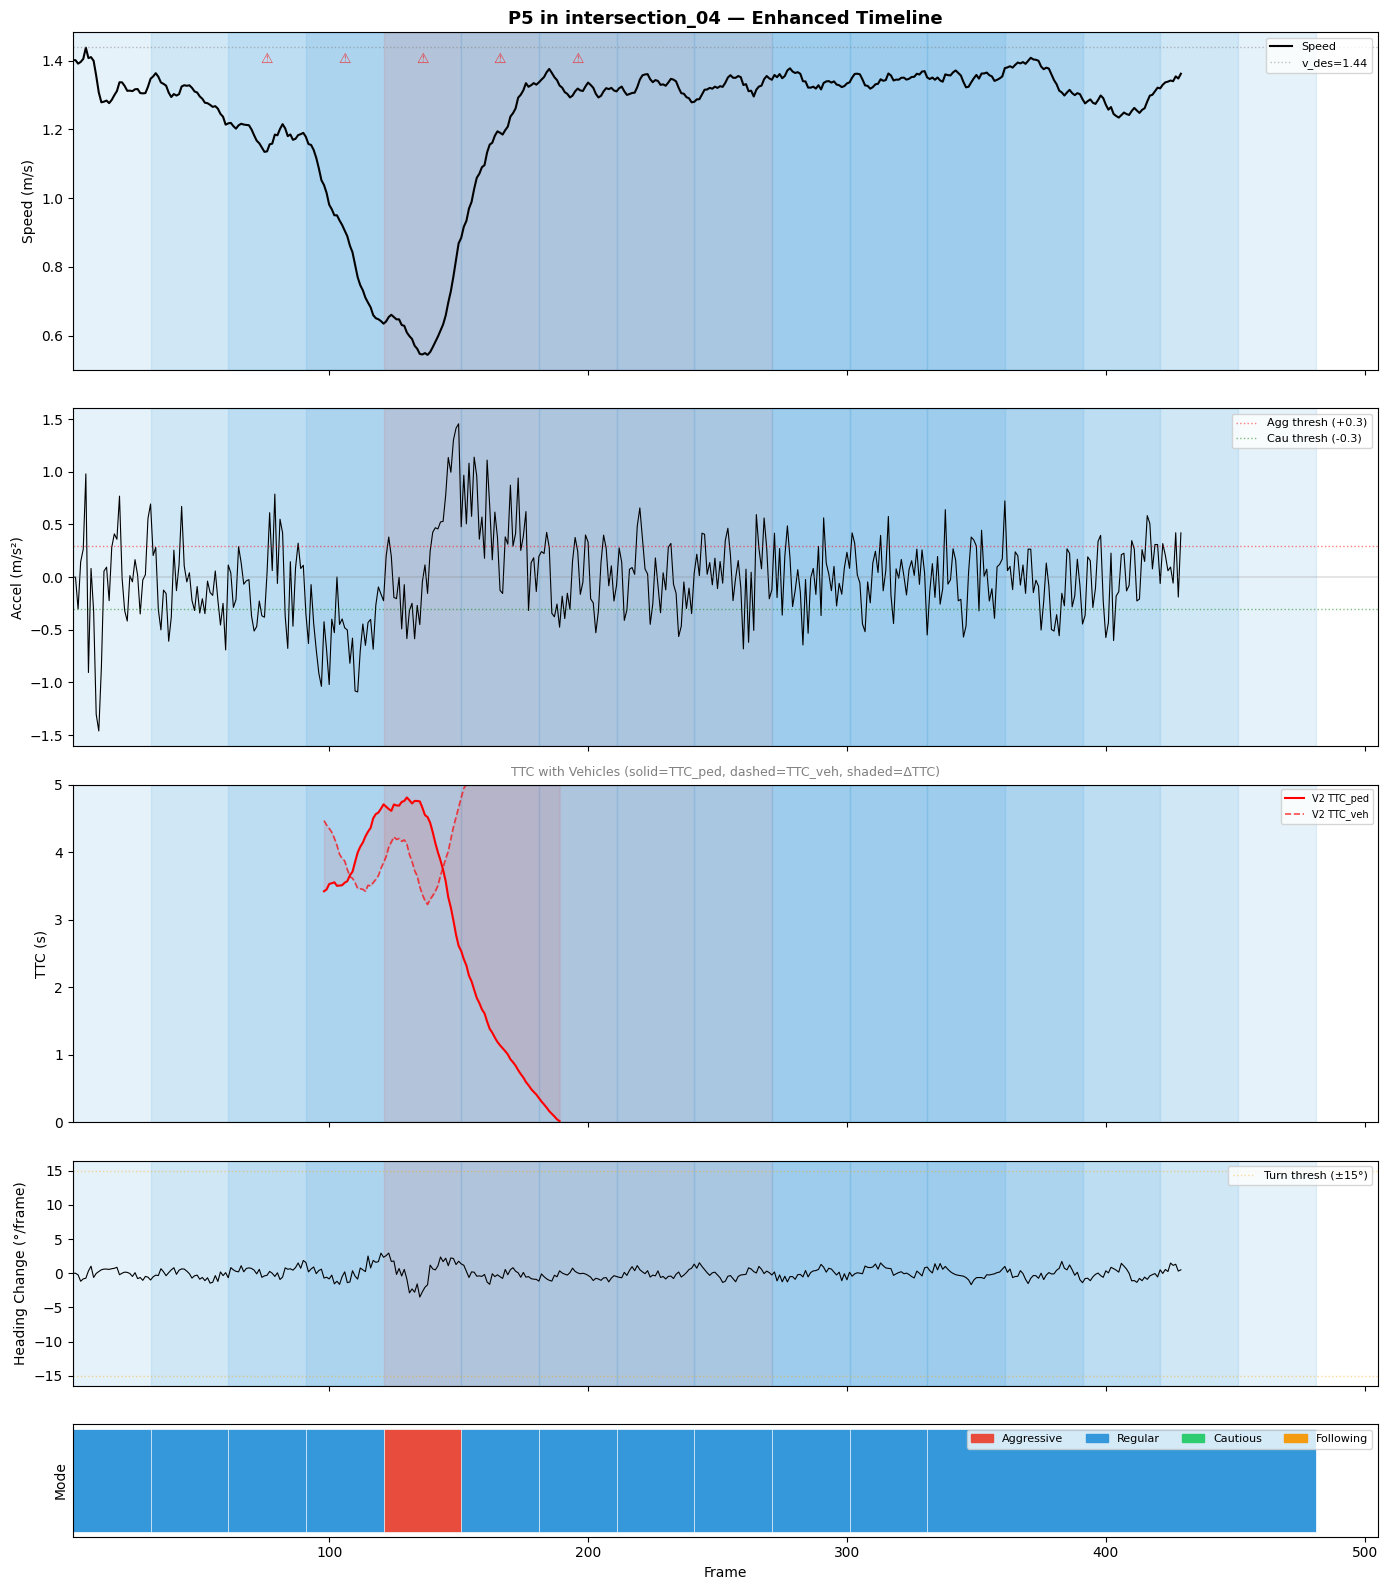


Window labels for P5:
  Start-  End | Mode         | Conf |  Speed |   Accel |  ΔTTC_i | Tp_min | Tv_min
  ----------------------------------------------------------------------------------
      1-  151 | Regular      | Yes  |  1.071 |  -0.107 |   -0.32 |   3.55 |   3.37
     31-  181 | Regular      | Yes  |  1.037 |  -0.003 |   -0.32 |   1.14 |   3.37
     61-  211 | Regular      | Yes  |  1.041 |  +0.019 |   -0.32 |   0.36 |   3.37
     91-  241 | Regular      | Yes  |  1.069 |  +0.020 |   -0.32 |   0.36 |   3.37
    121-  271 | Aggressive   | Yes  |  1.155 |  +0.144 |   +0.86 |   0.36 |   3.37
    151-  301 | Regular      | No   |  1.296 |  +0.090 |   -2.27 |   0.36 |   4.81
    181-  331 | Regular      | No   |  1.333 |  +0.007 |    +nan |    inf |    inf
    211-  361 | Regular      | No   |  1.338 |  +0.009 |    +nan |    inf |    inf
    241-  391 | Regular      | No   |  1.345 |  +0.005 |    +nan |    inf |    inf
    271-  421 | Regular      | No   |  1.334 |  -0.005 |    +n

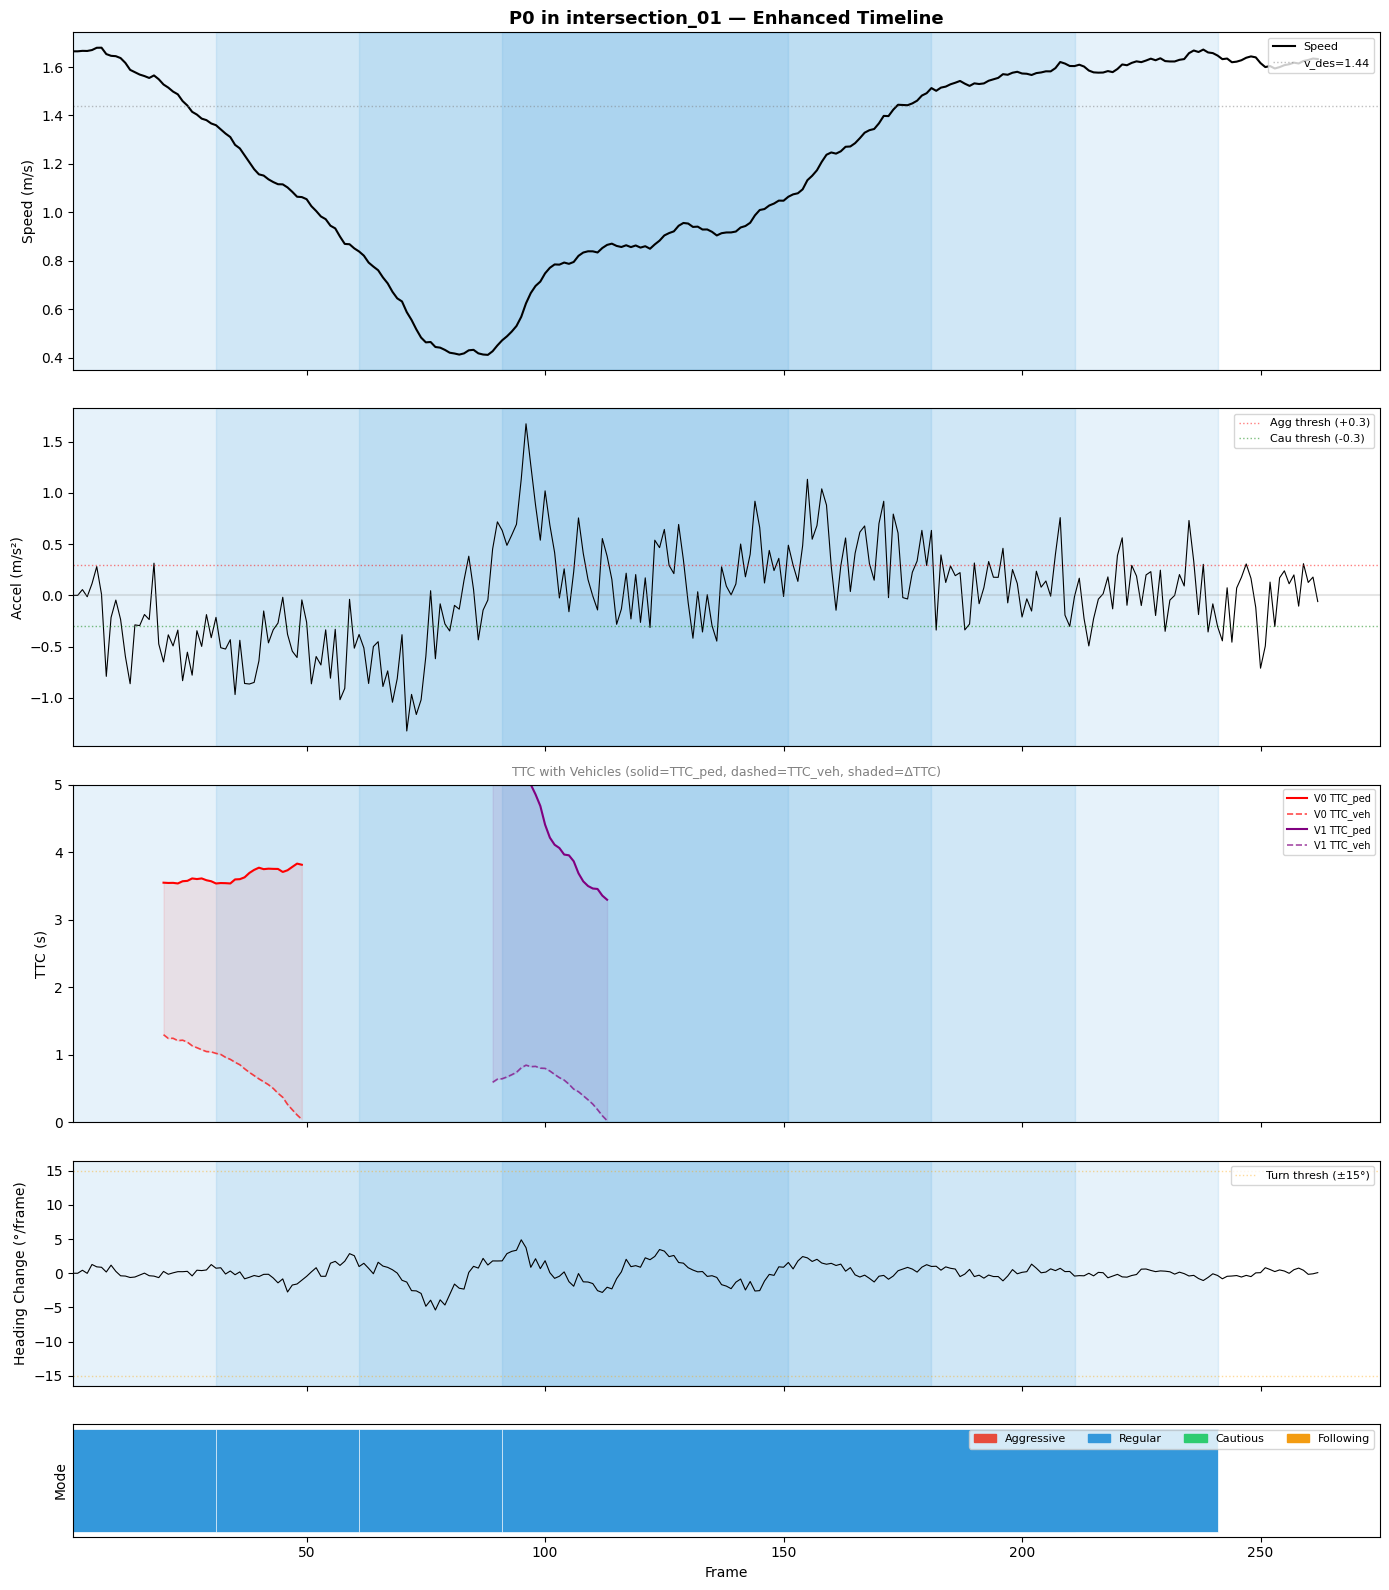


Window labels for P0:
  Start-  End | Mode         | Conf |  Speed |   Accel |  ΔTTC_i | Tp_min | Tv_min
  ----------------------------------------------------------------------------------
      1-  151 | Regular      | No   |  0.981 |  -0.124 |   +2.51 |   3.54 |   0.27
     31-  181 | Regular      | No   |  0.928 |  +0.027 |   +2.51 |   3.54 |   0.27
     61-  211 | Regular      | No   |  1.020 |  +0.154 |    +nan |    inf |    inf
     91-  241 | Regular      | No   |  1.234 |  +0.239 |    +nan |    inf |    inf

===== CAUTIOUS example: P83 in intersection_04 =====


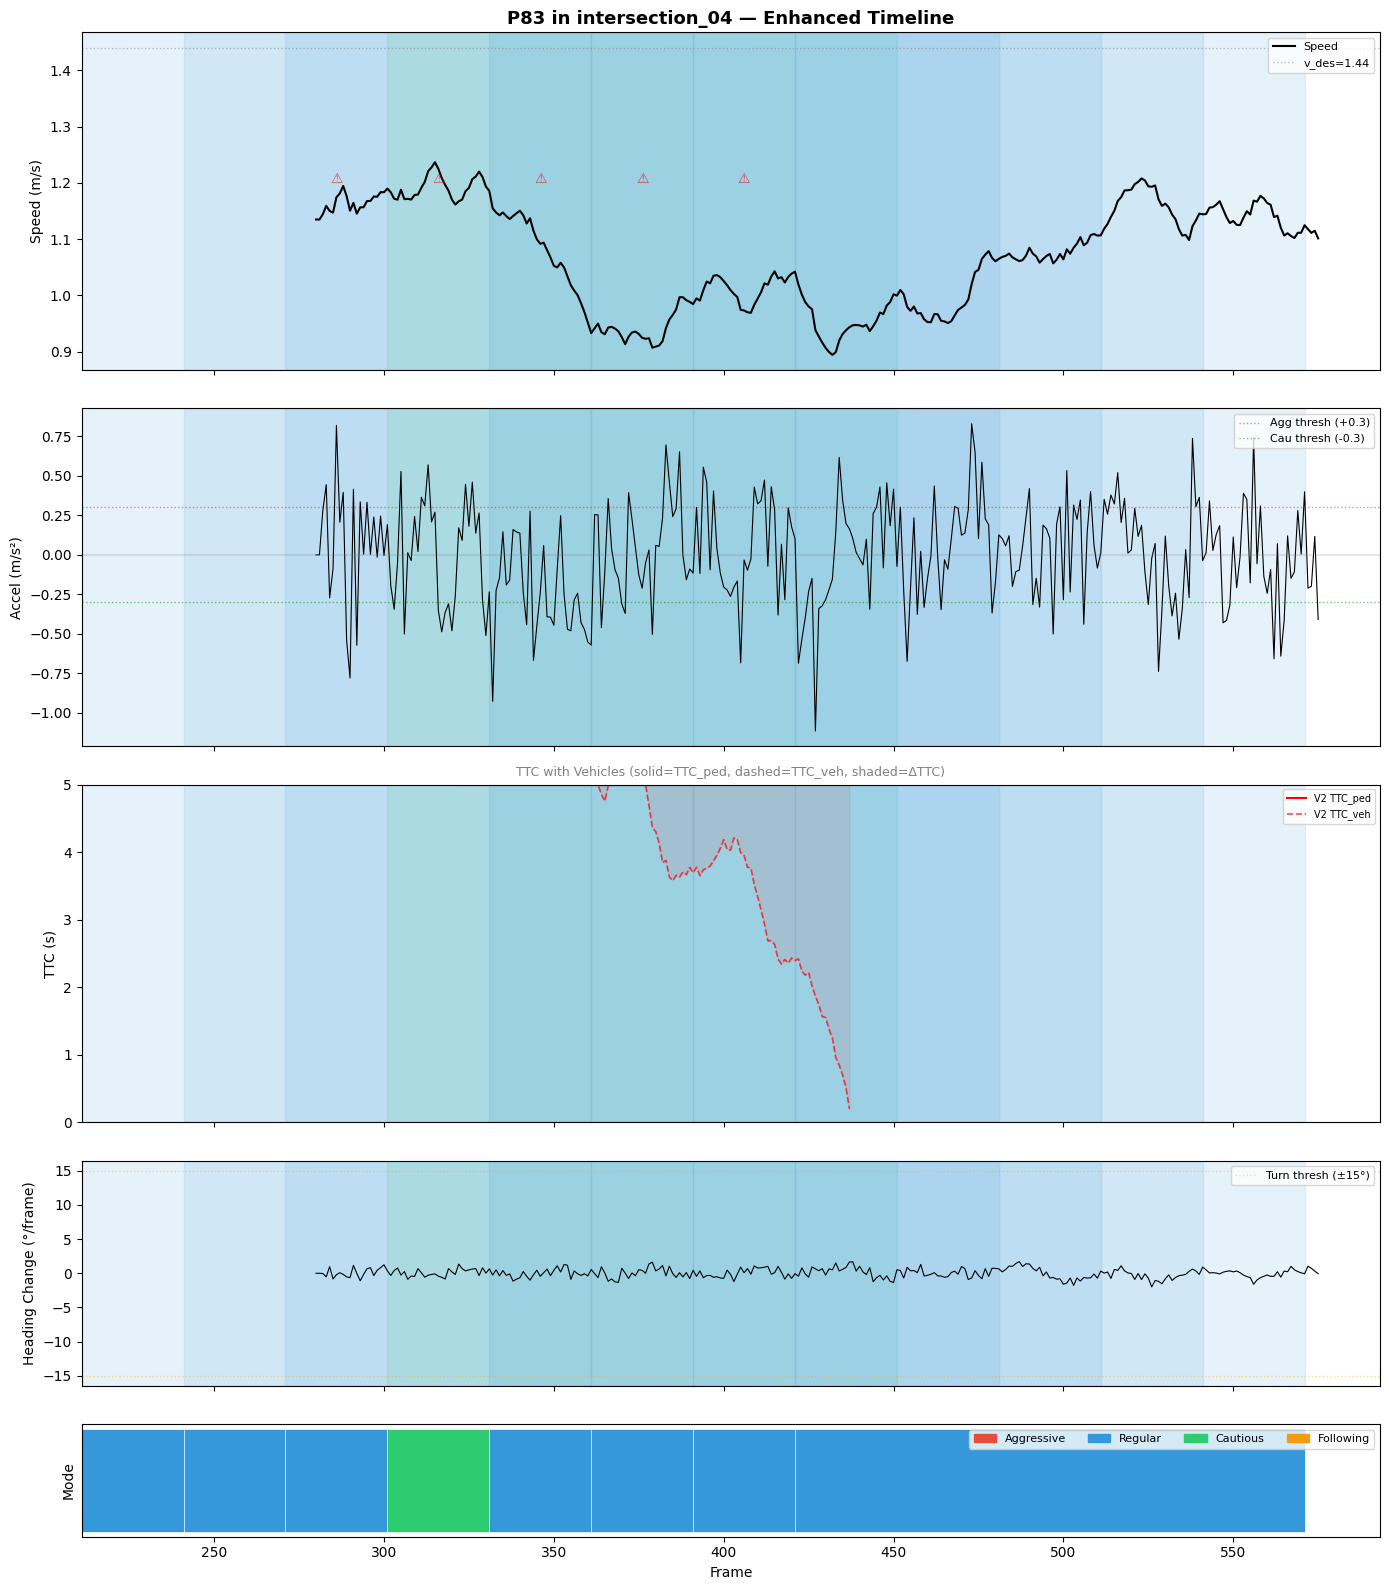


Window labels for P83:
  Start-  End | Mode         | Conf |  Speed |   Accel |  ΔTTC_i | Tp_min | Tv_min
  ----------------------------------------------------------------------------------
    211-  361 | Regular      | Yes  |  1.146 |  -0.069 |   -3.68 |   7.91 |   5.26
    241-  391 | Regular      | Yes  |  1.091 |  -0.040 |   -3.68 |   7.27 |   3.77
    271-  421 | Regular      | Yes  |  1.074 |  -0.021 |   -3.68 |   5.68 |   2.43
    301-  451 | Cautious     | Yes  |  1.037 |  -0.038 |   -1.95 |   5.62 |   0.52
    331-  481 | Regular      | Yes  |  0.998 |  -0.025 |   +0.59 |   5.62 |   0.52
    361-  511 | Regular      | No   |  0.995 |  +0.035 |   +3.85 |   5.62 |   0.52
    391-  541 | Regular      | No   |  1.038 |  +0.032 |   +3.54 |   5.62 |   0.52
    421-  571 | Regular      | No   |  1.064 |  +0.014 |    +nan |    inf |    inf

===== FOLLOWING example: P2 in intersection_02 =====


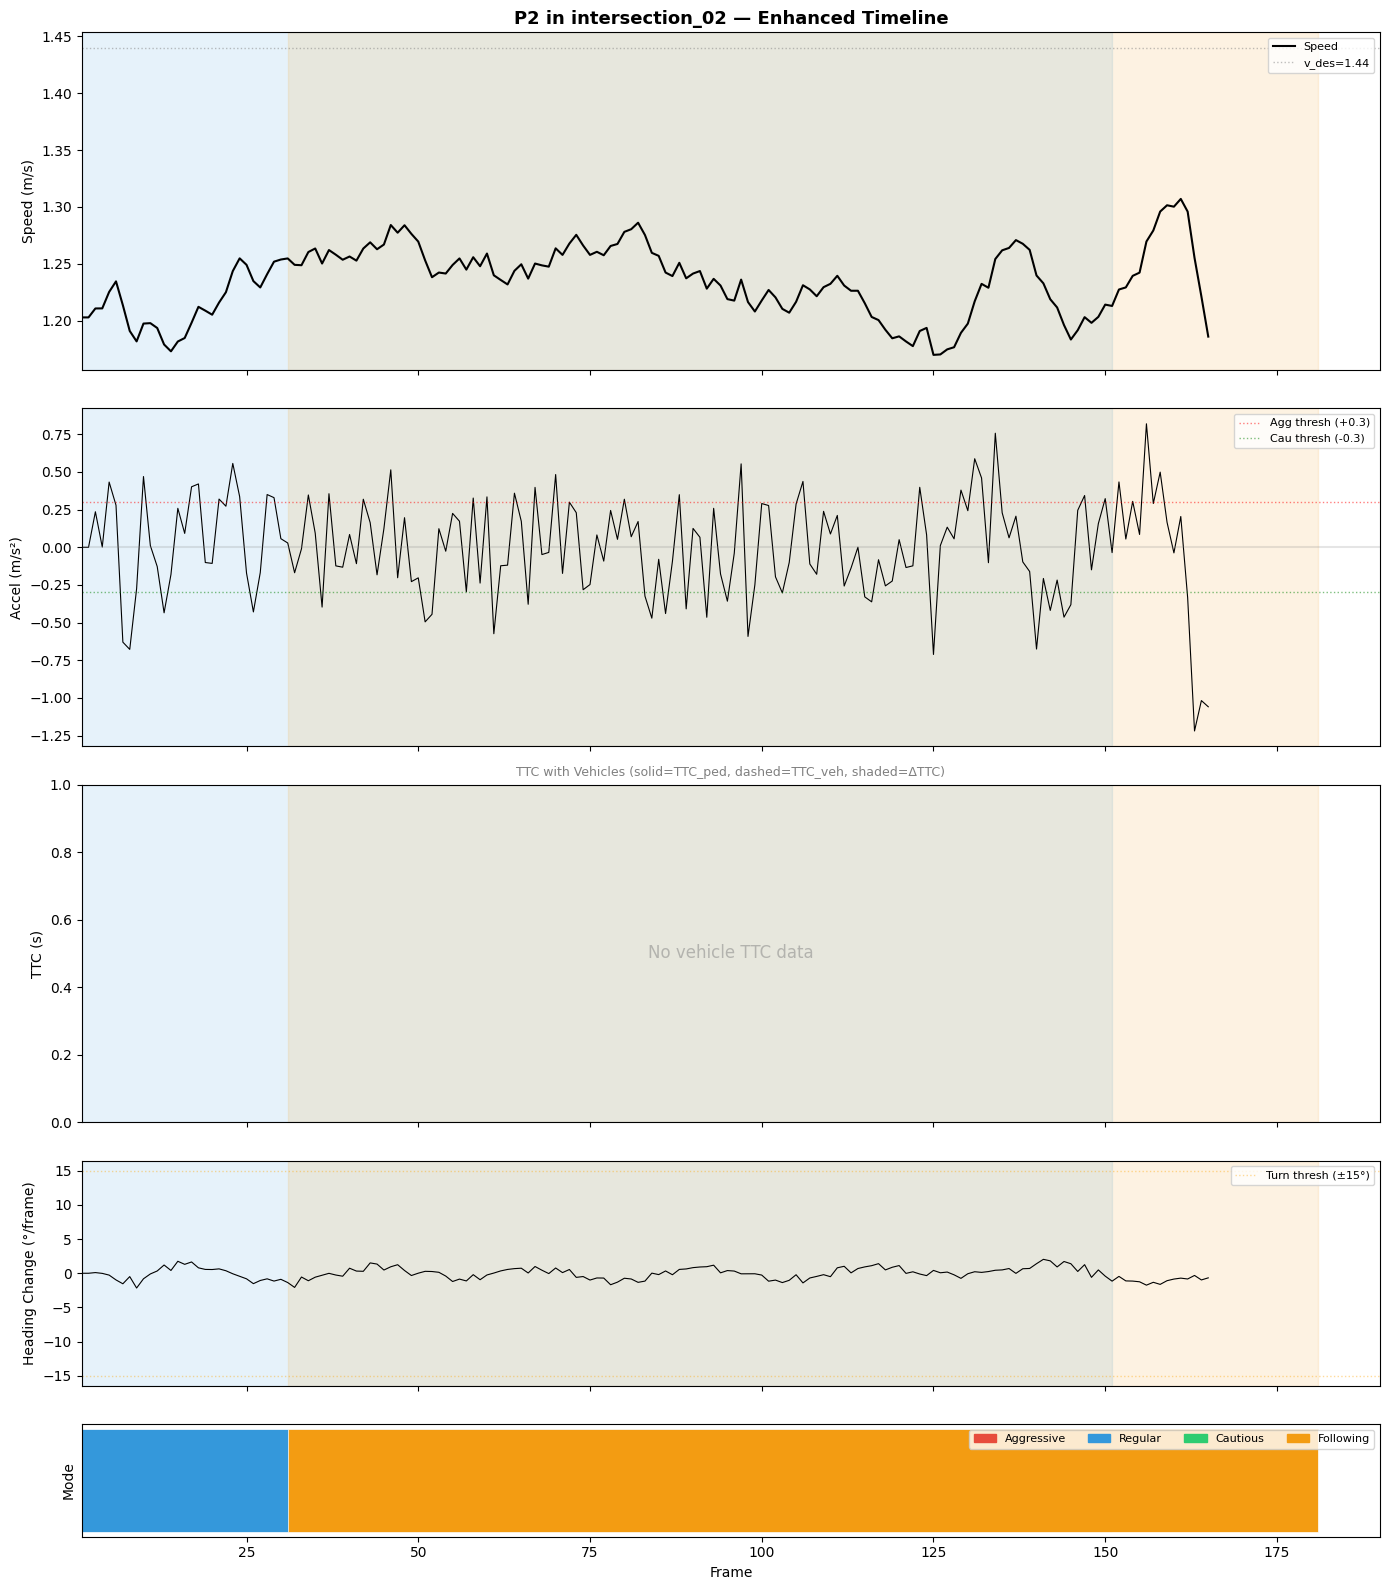


Window labels for P2:
  Start-  End | Mode         | Conf |  Speed |   Accel |  ΔTTC_i | Tp_min | Tv_min
  ----------------------------------------------------------------------------------
      1-  151 | Regular      | No   |  1.232 |  +0.002 |    +nan |    inf |    inf
     31-  181 | Following    | No   |  1.239 |  -0.015 |    +nan |    inf |    inf


In [10]:
# Cell 8: Pick pedestrians to inspect
#
# Auto-select one from each mode for verification
import matplotlib.patches as mpatches

for mode_id, mode_name in enumerate(MODE_NAMES):
    subset = labels_df[labels_df['mode'] == mode_id]
    if subset.empty:
        print(f'No {mode_name} samples found.')
        continue
    sample = subset.iloc[0]
    sc = sample.get('scenario', '')
    pid = int(sample['ped_id'])
    print(f'\n===== {mode_name.upper()} example: P{pid} in {sc} =====')
    if sc:
        plot_ped_timeline(sc, pid)   # ← changed from plot_ped_timeline

In [11]:
# Cell 11: Save Verified Labels
#
# After visual verification, save the final labels for GNN training.

output_path = r'/Volumes/Seagate129/P2V_Interaction_Modeling/Data/campus_field/pseudo_labels.csv'
labels_df.to_csv(output_path, index=False)
print(f'Labels saved to: {output_path}')
print(f'Total: {len(labels_df)} samples across {labels_df["scenario"].nunique() if "scenario" in labels_df.columns else "?"} scenarios')
print(f'\nReady for GNN training!')

Labels saved to: /Volumes/Seagate129/P2V_Interaction_Modeling/Data/campus_field/pseudo_labels.csv
Total: 10982 samples across 28 scenarios

Ready for GNN training!
